# **Importing Modules and Libraries**

In [176]:
# importing required libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
from os import path

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# **Importing Datasets**

In [177]:
# import os
# from google.colab import drive

# Mount Google Drive
# drive.mount('/content/gdrive')
# os.chdir('/content/gdrive/MyDrive/Papi')
!wget "https://drive.google.com/uc?export=download&id=1cPlyRYexAZPZv8r2vPOfNmapgdiBYnb_" -O "UNSW_NB15.csv"

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [178]:
#data = pd.read_csv('/content/drive/MyDrive/IoT_ML_Dataset/UNSW/UNSW_NB15.csv')
data = pd.read_csv('UNSW_NB15.csv')

In [179]:
data.head(n=5)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [180]:
data.info() # in ra thông tin cấu trúc của DataFrame.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [181]:
data[data['service']=='-'] #Lọc các dòng có giá trị service là '-'

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0
5,6,0.380537,tcp,-,FIN,10,6,534,268,39.417980,...,1,40,0,0,0,2,39,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175125,175126,0.653375,tcp,-,FIN,10,8,564,354,26.018748,...,1,1,0,0,0,18,1,0,Reconnaissance,1
175179,175180,0.695566,tcp,-,FIN,10,8,564,354,24.440528,...,1,1,0,0,0,3,1,0,Reconnaissance,1
175191,175192,0.962856,tcp,-,FIN,24,60,1256,59374,86.201883,...,1,1,0,0,0,1,1,0,Exploits,1
175277,175278,3.719110,tcp,-,FIN,66,340,3086,426483,108.897021,...,1,1,0,0,0,2,1,0,Exploits,1


In [182]:
data['service'].replace('-',np.nan,inplace=True) # Thay thế các giá trị '-' trong cột 'service' bằng NaN
# biểu thị giá trị thiếu → pandas và các hàm thống kê không hiểu '-'.

C:\Users\asus\AppData\Local\Temp\ipykernel_62368\2606979873.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['service'].replace('-',np.nan,inplace=True) # Thay thế các giá trị '-' trong cột 'service' bằng NaN


In [183]:
data.isnull().sum()

id                       0
dur                      0
proto                    0
service              94168
state                    0
spkts                    0
dpkts                    0
sbytes                   0
dbytes                   0
rate                     0
sttl                     0
dttl                     0
sload                    0
dload                    0
sloss                    0
dloss                    0
sinpkt                   0
dinpkt                   0
sjit                     0
djit                     0
swin                     0
stcpb                    0
dtcpb                    0
dwin                     0
tcprtt                   0
synack                   0
ackdat                   0
smean                    0
dmean                    0
trans_depth              0
response_body_len        0
ct_srv_src               0
ct_state_ttl             0
ct_dst_ltm               0
ct_src_dport_ltm         0
ct_dst_sport_ltm         0
ct_dst_src_ltm           0
i

In [184]:
data.shape
#data.shape trả về một tuple (rows, columns)

(175341, 45)

In [185]:
data.dropna(inplace=True)
#tất cả dòng mà có ít nhất một giá trị thiếu (NaN) sẽ bị xóa khỏi DataFrame.
# inplace=True: thay đổi được thực hiện trực tiếp trên DataFrame gốc mà không cần tạo bản sao.

In [186]:
data.shape

(81173, 45)

In [187]:
data['attack_cat'].value_counts()
# Chọn cột attack_cat và đếm số lần xuất hiện của mỗi giá trị duy nhất trong cột đó.

attack_cat
Generic           39496
Normal            19488
Exploits          16187
DoS                1791
Fuzzers            1731
Reconnaissance     1703
Analysis            564
Worms               114
Backdoor             99
Name: count, dtype: int64

In [188]:
data['label'].value_counts()


label
1    61685
0    19488
Name: count, dtype: int64

In [189]:
data['state'].value_counts()

state
INT    39580
FIN    33640
CON     7711
REQ      228
RST       14
Name: count, dtype: int64

In [190]:
data

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
11,12,2.093085,tcp,smtp,FIN,62,28,56329,2212,42.520967,...,1,2,0,0,0,1,1,0,Normal,0
15,16,0.000002,udp,snmp,INT,2,0,138,0,500000.001300,...,1,4,0,0,0,2,1,0,Normal,0
17,18,0.393556,tcp,http,FIN,10,8,860,1096,43.195886,...,1,2,0,0,1,1,3,0,Normal,0
21,22,0.338017,tcp,http,FIN,10,6,998,268,44.376468,...,1,1,0,0,1,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175335,175336,0.000006,udp,dns,INT,2,0,114,0,166666.660800,...,17,45,0,0,0,33,45,0,Generic,1
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


In [191]:
!wget "https://drive.google.com/uc?export=download&id=1D3hkSlWkWJ4SzFT5q0BMkebYweVm1dVi" -O "UNSW_NB15_features.csv"

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [192]:
#features = pd.read_csv('/content/drive/MyDrive/IoT_ML_Dataset/UNSW/UNSW_NB15_features.csv')
features = pd.read_csv('UNSW_NB15_features.csv')

In [193]:
features
# features.info()

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [194]:
features['Type '] = features['Type '].str.lower()

In [195]:
# selecting column names of all data types
nominal_names = features['Name'][features['Type ']=='nominal']
integer_names = features['Name'][features['Type ']=='integer']
binary_names = features['Name'][features['Type ']=='binary']
float_names = features['Name'][features['Type ']=='float']

In [196]:
# selecting common column names from dataset and feature dataset
#iểm tra xem những cột này thực sự tồn tại trong data hay không
cols = data.columns
nominal_names = cols.intersection(nominal_names)
integer_names = cols.intersection(integer_names)
binary_names = cols.intersection(binary_names)
float_names = cols.intersection(float_names)

In [197]:
# Converting integer columns to numeric
for c in integer_names:
  pd.to_numeric(data[c])

In [198]:
# Converting binary columns to numeric
for c in binary_names:
  pd.to_numeric(data[c])

In [199]:
# Converting float columns to numeric
for c in float_names:
  pd.to_numeric(data[c])

In [200]:
data.info()
#numeric — điều này nghĩa là các cột dạng object (chuỗi) sẽ được chuyển sang dạng số (ví dụ bằng LabelEncoder hoặc One-Hot Encoding), để mô hình học máy hiểu được.


<class 'pandas.core.frame.DataFrame'>
Index: 81173 entries, 3 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 81173 non-null  int64  
 1   dur                81173 non-null  float64
 2   proto              81173 non-null  object 
 3   service            81173 non-null  object 
 4   state              81173 non-null  object 
 5   spkts              81173 non-null  int64  
 6   dpkts              81173 non-null  int64  
 7   sbytes             81173 non-null  int64  
 8   dbytes             81173 non-null  int64  
 9   rate               81173 non-null  float64
 10  sttl               81173 non-null  int64  
 11  dttl               81173 non-null  int64  
 12  sload              81173 non-null  float64
 13  dload              81173 non-null  float64
 14  sloss              81173 non-null  int64  
 15  dloss              81173 non-null  int64  
 16  sinpkt             81173 n

In [201]:
data

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
11,12,2.093085,tcp,smtp,FIN,62,28,56329,2212,42.520967,...,1,2,0,0,0,1,1,0,Normal,0
15,16,0.000002,udp,snmp,INT,2,0,138,0,500000.001300,...,1,4,0,0,0,2,1,0,Normal,0
17,18,0.393556,tcp,http,FIN,10,8,860,1096,43.195886,...,1,2,0,0,1,1,3,0,Normal,0
21,22,0.338017,tcp,http,FIN,10,6,998,268,44.376468,...,1,1,0,0,1,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175335,175336,0.000006,udp,dns,INT,2,0,114,0,166666.660800,...,17,45,0,0,0,33,45,0,Generic,1
175336,175337,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,13,24,0,0,0,24,24,0,Generic,1
175338,175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,3,13,0,0,0,3,12,0,Generic,1
175339,175340,0.000009,udp,dns,INT,2,0,114,0,111111.107200,...,14,30,0,0,0,30,30,0,Generic,1


# **Data Visualization**

## **Binary Classification**

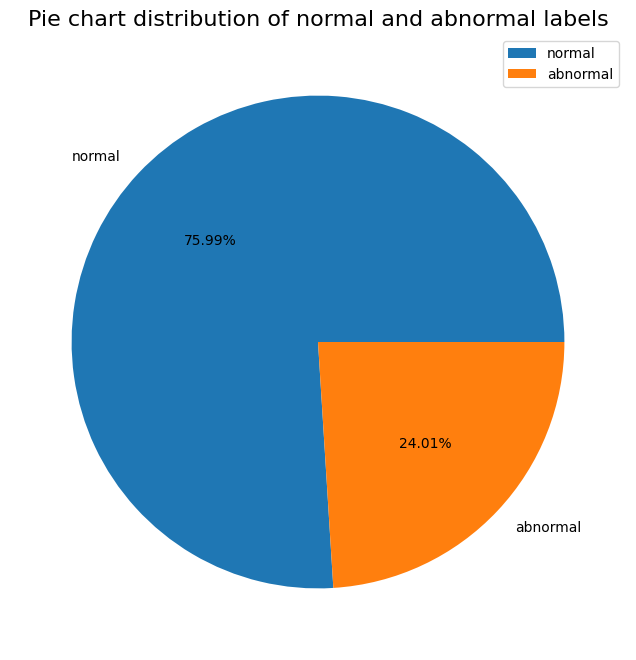

In [202]:
plt.figure(figsize=(8,8))
plt.pie(data.label.value_counts(),labels=['normal','abnormal'],autopct='%0.2f%%')
plt.title("Pie chart distribution of normal and abnormal labels",fontsize=16)
plt.legend()
# plt.savefig('plots/Pie_chart_binary.png')
plt.show()

## **Multi-class Classification**

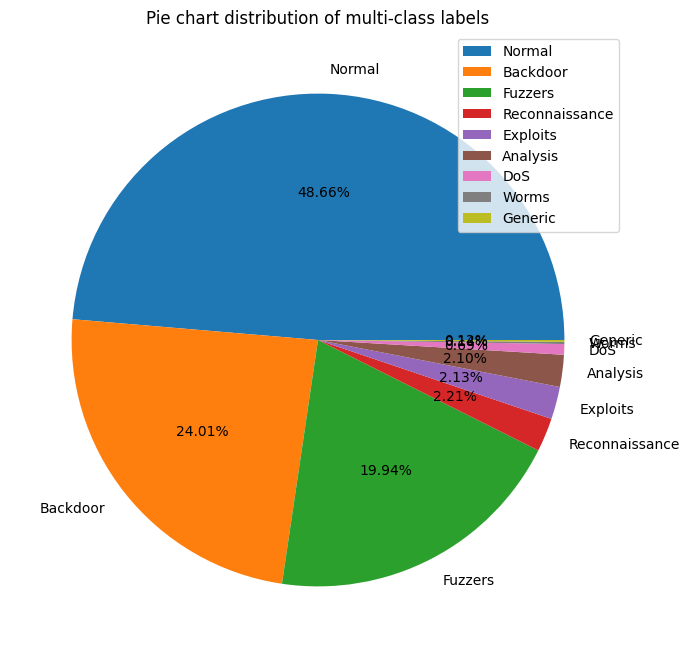

In [203]:
plt.figure(figsize=(8,8))
plt.pie(data.attack_cat.value_counts(),labels=data.attack_cat.unique(),autopct='%0.2f%%')
plt.title('Pie chart distribution of multi-class labels')
plt.legend(loc='best')
# plt.savefig('plots/Pie_chart_multi.png')
plt.show()
#→ Lúc này model phải phân biệt nhiều loại tấn công khác nhau, 
# chứ không chỉ "tấn công" hay "không".

# **One hot encoding**

In [204]:
num_col = data.select_dtypes(include='number').columns

# selecting categorical data attributes
cat_col = data.columns.difference(num_col) # loại trừ kiểu số để ra phân loại
cat_col = cat_col[1:]
cat_col
#tách riêng cột dạng phân loại (categorical) 
# ra khỏi dữ liệu gốc để chuẩn bị mã hóa (encoding).

Index(['proto', 'service', 'state'], dtype='object')

In [205]:
# creating a dataframe with only categorical attributes
data_cat = data[cat_col].copy()
data_cat.head(n=10)
#thì data_cat chỉ là một view (ảnh chiếu) 
# của DataFrame data gốc — nghĩa là:nếu bro thay đổi dữ liệu 
# trong data_cat, có thể ảnh hưởng trực tiếp tới data gốc (hoặc ngược lại).

,proto,service,state
3,tcp,ftp,FIN
11,tcp,smtp,FIN
15,udp,snmp,INT
17,tcp,http,FIN
21,tcp,http,FIN
22,tcp,ftp,CON
28,tcp,http,FIN
30,tcp,http,FIN
31,tcp,http,FIN
32,tcp,http,FIN


In [206]:
# one-hot-encoding categorical attributes using pandas.get_dummies() function
##Hàm của pandas để tự động mã hóa one-hot
data_cat = pd.get_dummies(data_cat,columns=cat_col)
#Máy học (ML model) không hiểu chữ, nó chỉ hiểu số.
#→ One-hot encoding sẽ chuyển từng giá trị duy nhất (unique) thành một cột nhị phân (0 hoặc 1).
#| proto_tcp | proto_udp | state_FIN | state_EST | state_INT |
#| --------- | --------- | --------- | --------- | --------- |
#| 1         | 0         | 1         | 0         | 0         |
#| 0         | 1         | 0         | 1         | 0         |
#| 1         | 0         | 0         | 0         | 1         |
#kiểu protoco tách thành 2 cột riêng biệt

In [207]:
data_cat.head()

,proto_tcp,proto_udp,service_dhcp,service_dns,service_ftp,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_CON,state_FIN,state_INT,state_REQ,state_RST
3,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False
11,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
15,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
17,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
21,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False


In [208]:
data.shape



(81173, 45)

In [209]:
data = pd.concat([data, data_cat],axis=1)
#➡ Gộp các cột mới (đã mã hóa) từ data_cat vào data gốc


In [210]:
data.shape

(81173, 64)

In [211]:
data.drop(columns=cat_col,inplace=True)

In [212]:
data.shape

(81173, 61)

# **Data Normalization**


In [213]:
# selecting numeric attributes columns from data
num_col = list(data.select_dtypes(include='number').columns)
num_col.remove('id')
num_col.remove('label')
print(num_col)
#num_col là danh sách các cột số thực sự cần chuẩn hóa

['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [214]:
# using minmax scaler for normalizing data
minmax_scale = MinMaxScaler(feature_range=(0, 1)) #range 0,1
def normalization(df,col):
  for i in col:
    arr = df[i]
    arr = np.array(arr)
    df[i] = minmax_scale.fit_transform(arr.reshape(len(arr),1))
  return df
##phương pháp Min–Max Scaling,

In [215]:
# data before normalization
data.head()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_CON,state_FIN,state_INT,state_REQ,state_RST
3,4,1.681642,12,12,628,770,13.677108,62,252,2.740179e+03,...,False,False,False,False,False,False,True,False,False,False
11,12,2.093085,62,28,56329,2212,42.520967,62,252,2.118251e+05,...,False,True,False,False,False,False,True,False,False,False
15,16,0.000002,2,0,138,0,500000.001300,254,0,2.760000e+08,...,False,False,True,False,False,False,False,True,False,False
17,18,0.393556,10,8,860,1096,43.195886,62,252,1.573347e+04,...,False,False,False,False,False,False,True,False,False,False
21,22,0.338017,10,6,998,268,44.376468,254,252,2.127704e+04,...,False,False,False,False,False,False,True,False,False,False


In [216]:
# calling normalization() function
data = normalization(data.copy(),num_col)

In [217]:
# data after normalization
data.head()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_CON,state_FIN,state_INT,state_REQ,state_RST
3,4,2.802780e-02,0.001144,0.001093,0.000041,0.000053,0.000014,0.138393,0.992126,0.000001,...,False,False,False,False,False,False,True,False,False,False
11,12,3.488529e-02,0.006344,0.002551,0.004337,0.000151,0.000043,0.138393,0.992126,0.000092,...,False,True,False,False,False,False,True,False,False,False
15,16,1.666693e-08,0.000104,0.000000,0.000003,0.000000,0.500000,0.995536,0.000000,0.119792,...,False,False,True,False,False,False,False,True,False,False
17,18,6.559354e-03,0.000936,0.000729,0.000059,0.000075,0.000043,0.138393,0.992126,0.000007,...,False,False,False,False,False,False,True,False,False,False
21,22,5.633690e-03,0.000936,0.000547,0.000069,0.000018,0.000044,0.995536,0.992126,0.000009,...,False,False,False,False,False,False,True,False,False,False


# **Label Encoding**

## **Binary Labels**

In [218]:
# changing attack labels into two categories 'normal' and 'abnormal'
bin_label = pd.DataFrame(data.label.map(lambda x:'normal' if x==0 else 'abnormal'))
#phân loại label 0 thành 'normal', các giá trị khác thành 'abnormal'

In [219]:
# creating a dataframe with binary labels (normal,abnormal)
bin_data = data.copy() #copy lại để ko ảnh hg bản gốc
bin_data['label'] = bin_label

In [220]:
# label encoding (0,1) binary labels
le1 = preprocessing.LabelEncoder()
enc_label = bin_label.apply(le1.fit_transform) #học và gán mã số cho từng giá trị khác nhau.
bin_data['label'] = enc_label #áp dụng cho toàn bộ cột label.

In [221]:
le1.classes_

array(['abnormal', 'normal'], dtype=object)

In [222]:
np.save("le1_classes.npy",le1.classes_,allow_pickle=True)

## **Multi-class Labels**

In [223]:

# one-hot-encoding attack label
multi_data = data.copy()
multi_label = pd.DataFrame(multi_data.attack_cat)

In [224]:
multi_data = pd.get_dummies(multi_data,columns=['attack_cat'])

In [225]:
# label encoding (0,1,2,3,4,5,6,7,8) multi-class labels
le2 = preprocessing.LabelEncoder()
enc_label = multi_label.apply(le2.fit_transform)
multi_data['label'] = enc_label

In [226]:
# le2.classes_

In [227]:
# np.save("le2_classes.npy",le2.classes_,allow_pickle=True)

# **Correlation between features of dataset**

In [228]:
# num_col.append('label')
if num_col.count('label') > 0:
  num_col.remove('label')
if num_col.count('is_sm_ips_ports') > 0:
  num_col.remove('is_sm_ips_ports')
if num_col.count('id') > 0:
  num_col.remove('id')
  ##phân tích tương quan giwuxa các thuộc tính số
  ##loại bỏ những cột không cần tính tương quan 
  # (vì chúng không phải đặc trưng thực tế để phân tích).

## **Correlation Matrix for Binary Labels**

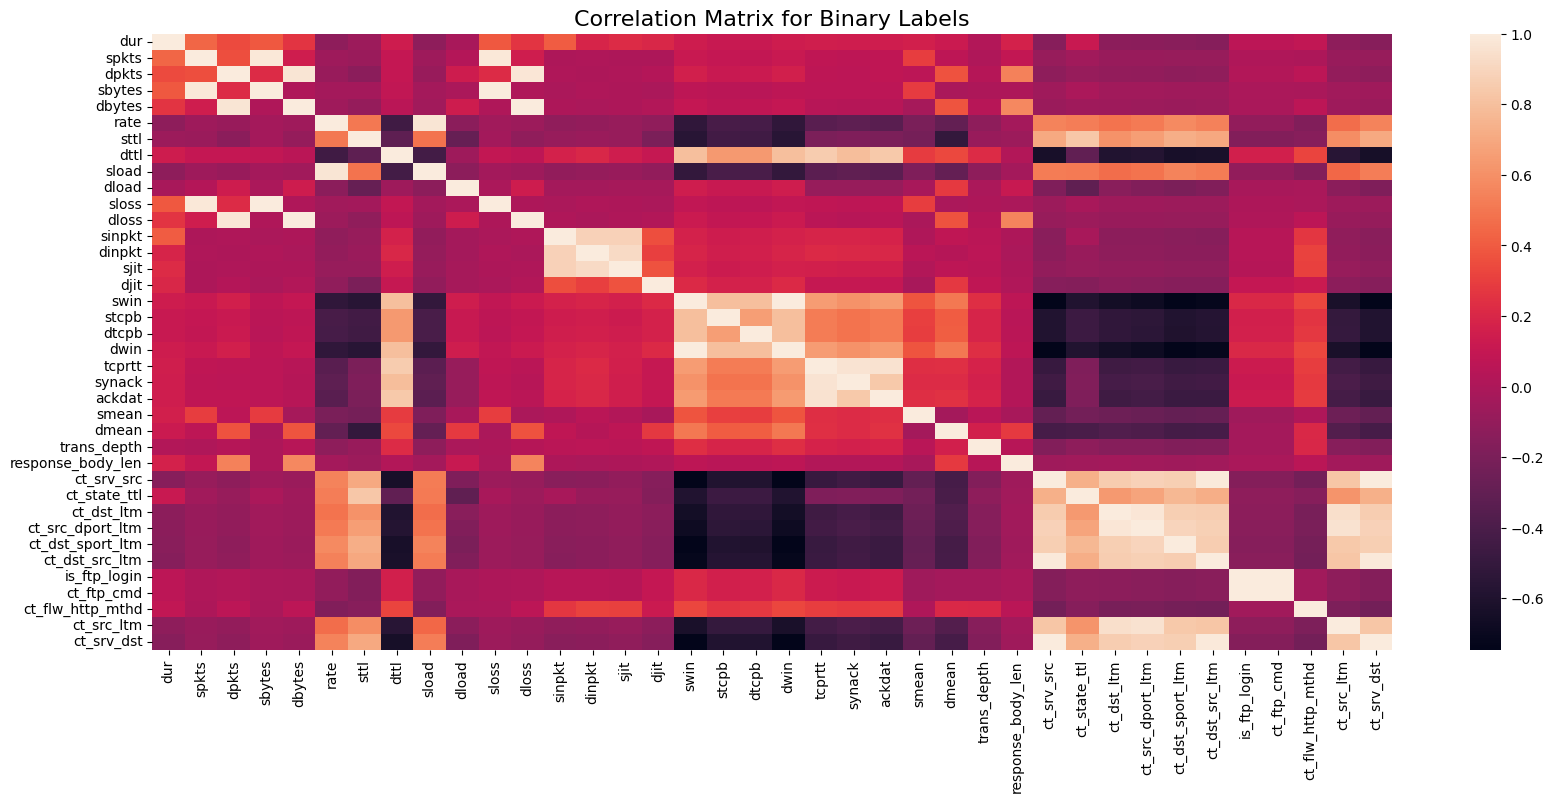

In [229]:
# Correlation Matrix for Binary Labels
plt.figure(figsize=(20,8))
corr_bin = bin_data[num_col].corr() #tính toán ma trận tương quan giữa các cột số trong bin_data
sns.heatmap(corr_bin,vmax=1.0,annot=False)
plt.title('Correlation Matrix for Binary Labels',fontsize=16)
# plt.savefig('plots/correlation_matrix_bin.png')
plt.show()
#màu nhạt  có mối tương quan mạnh,

## **Correlation Matrix for Multi-class Labels**

In [230]:
num_col = list(multi_data.select_dtypes(include='number').columns)
num_col.remove('label')
num_col.remove('is_sm_ips_ports')
num_col.remove('id')

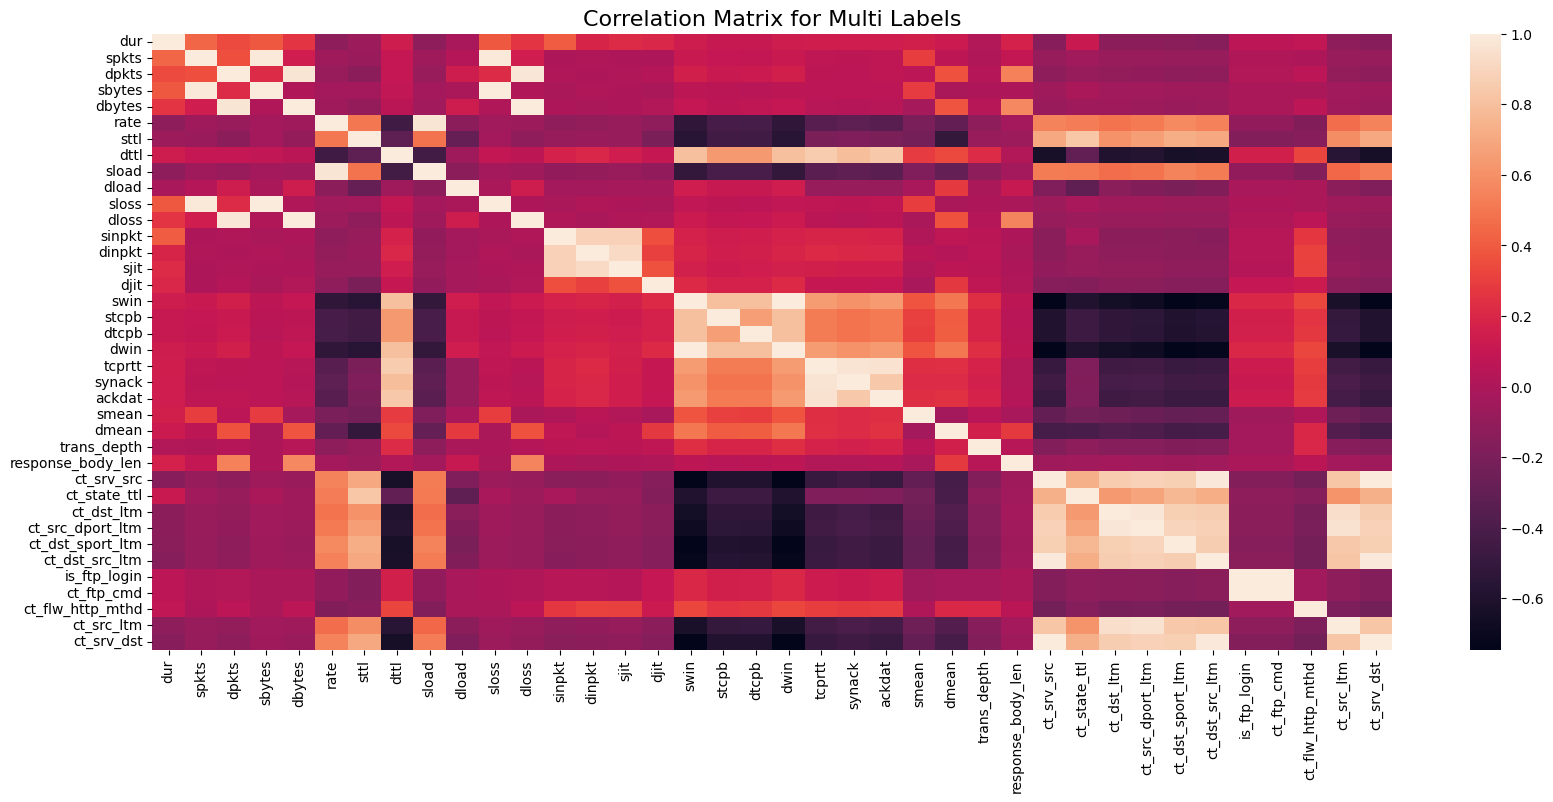

In [231]:
# Correlation Matrix for Multi-class Labels
plt.figure(figsize=(20,8))
corr_multi = multi_data[num_col].corr()
sns.heatmap(corr_multi,vmax=1.0,annot=False)
plt.title('Correlation Matrix for Multi Labels',fontsize=16)
# plt.savefig('plots/correlation_matrix_multi.png')
plt.show()
#Màu Nóng (Đỏ, Cam, Vàng, tiến về 1.0): Biểu thị tương quan dương mạnh
#Nghĩa là khi một biến tăng, biến kia cũng có xu hướng tăng theo 
# (và ngược lại, khi một biến giảm, biến kia cũng giảm).

# **Feature Selection**

## **Binary Labels**

In [232]:
# finding the attributes which have more than 0.3 correlation with encoded attack label attribute
#chọn đặc trưng dựa trên hệ số tương quan 
#tương quan cao với cột label (tức là biến mục tiêu cần dự đoán, ví dụ như tấn công / không tấn công, spam / không spam,...).
if num_col.count('label') < 1:
  num_col.append('label') #đảm bảo dsach num_col có cột 'label' vì cần label tính tương quan

corr_bin = bin_data[num_col].corr()
#→ Đây là ma trận hệ số Pearson (phạm vi từ -1 đến 1): 1 là tg quan hoàn hảo -1 ngược chiều 0 là 0
corr_ybin = abs(corr_bin['label'])
highest_corr_bin = corr_ybin[corr_ybin >0]
highest_corr_bin.sort_values(ascending=True)
#→ Tức là họ giữ những feature có tương quan Pearson ≥ 0.3 với label.
# Loại bỏ feature “ít liên quan” (ví dụ mấy cột IP, ID
#  không ảnh hưởng đến việc phân biệt attack/normal),

dinpkt               0.000054
spkts                0.010686
sloss                0.014274
sinpkt               0.015467
dur                  0.018005
sbytes               0.020540
trans_depth          0.021709
sjit                 0.029440
ct_flw_http_mthd     0.029566
dbytes               0.041428
response_body_len    0.045756
dloss                0.048563
is_ftp_login         0.050507
ct_ftp_cmd           0.050507
dpkts                0.063180
smean                0.102092
djit                 0.109551
dttl                 0.155827
synack               0.172863
dtcpb                0.181297
stcpb                0.184921
tcprtt               0.196270
ackdat               0.203839
swin                 0.227784
dwin                 0.227784
dmean                0.240989
sload                0.334562
dload                0.343910
rate                 0.344535
ct_src_ltm           0.368486
ct_dst_ltm           0.387358
ct_src_dport_ltm     0.444874
ct_srv_dst           0.459984
ct_srv_src

In [233]:
# highest_corr_bin = highest_corr_bin.drop(highest_corr_bin[highest_corr_bin.index == "sttl"].index)
# highest_corr_bin = highest_corr_bin.drop(highest_corr_bin[highest_corr_bin.index == "dttl"].index)
# highest_corr_bin = highest_corr_bin.drop(highest_corr_bin[highest_corr_bin.index == "ct_state_ttl"].index)
# highest_corr_bin = highest_corr_bin.drop(highest_corr_bin[highest_corr_bin.index == "tcprtt"].index)

In [234]:
# selecting attributes found by using pearson correlation coefficient
bin_cols = highest_corr_bin.index #tương quan vs label

In [235]:
bin_cols

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
       'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit',
       'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'label'],
      dtype='object')

In [236]:
# Binary labelled Dataset
bin_data = bin_data[bin_cols].copy()
bin_data

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,label
3,2.802780e-02,0.001144,0.001093,0.000041,0.000053,0.000014,0.138393,0.992126,0.000001,0.000150,...,0.02,0.00,0.000000,0.039216,0.25,0.25,0.000000,0.016949,0.000000,1
11,3.488529e-02,0.006344,0.002551,0.004337,0.000151,0.000043,0.138393,0.992126,0.000092,0.000364,...,0.00,0.00,0.000000,0.019608,0.00,0.00,0.000000,0.000000,0.000000,1
15,1.666693e-08,0.000104,0.000000,0.000003,0.000000,0.500000,0.995536,0.000000,0.119792,0.000000,...,0.00,0.00,0.000000,0.058824,0.00,0.00,0.000000,0.016949,0.000000,1
17,6.559354e-03,0.000936,0.000729,0.000059,0.000075,0.000043,0.138393,0.992126,0.000007,0.000869,...,0.00,0.00,0.000000,0.019608,0.00,0.00,0.033333,0.000000,0.039216,1
21,5.633690e-03,0.000936,0.000547,0.000069,0.000018,0.000044,0.995536,0.992126,0.000009,0.000236,...,0.00,0.00,0.000000,0.000000,0.00,0.00,0.033333,0.016949,0.039216,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175335,8.333466e-08,0.000104,0.000000,0.000001,0.000000,0.166667,0.995536,0.000000,0.032986,0.000000,...,0.64,0.64,0.533333,0.862745,0.00,0.00,0.000000,0.542373,0.862745,0
175336,1.333355e-07,0.000104,0.000000,0.000001,0.000000,0.111111,0.995536,0.000000,0.021991,0.000000,...,0.46,0.46,0.400000,0.450980,0.00,0.00,0.000000,0.389831,0.450980,0
175338,1.333355e-07,0.000104,0.000000,0.000001,0.000000,0.111111,0.995536,0.000000,0.021991,0.000000,...,0.04,0.04,0.066667,0.235294,0.00,0.00,0.000000,0.033898,0.215686,0
175339,1.333355e-07,0.000104,0.000000,0.000001,0.000000,0.111111,0.995536,0.000000,0.021991,0.000000,...,0.58,0.58,0.433333,0.568627,0.00,0.00,0.000000,0.491525,0.568627,0


### **Saving Prepared Dataset to Disk**

In [237]:
# bin_data.to_csv('/Papi/bin_data.csv')

## **Multi-class Labels**

In [ ]:
# finding the attributes which have more than 0.3 correlation with encoded attack label attribute
if num_col.count('label') < 1:
  num_col.append('label')

# corr_bin = bin_data[num_col].corr()
corr_multi = multi_data[num_col].corr()

corr_ymulti = abs(corr_multi['label'])
highest_corr_multi = corr_ymulti[corr_ymulti > 0.0]
#highest_corr_multi = corr_ymulti[corr_ymulti > 0.3] khi Feature Selection
highest_corr_multi.sort_values(ascending=True)

swin      0.364393
dwin      0.364393
synack    0.524027
ackdat    0.570098
tcprtt    0.570205
dttl      0.646589
label     1.000000
Name: label, dtype: float64

In [239]:
# highest_corr_multi = highest_corr_multi.drop(highest_corr_multi[highest_corr_multi.index == "sttl"].index)
# highest_corr_multi = highest_corr_multi.drop(highest_corr_multi[highest_corr_multi.index == "dttl"].index)
# highest_corr_multi = highest_corr_multi.drop(highest_corr_multi[highest_corr_multi.index == "ct_state_ttl"].index)
# highest_corr_multi = highest_corr_multi.drop(highest_corr_multi[highest_corr_multi.index == "tcprtt"].index)

In [240]:
# selecting attributes found by using pearson correlation coefficient
multi_cols = highest_corr_multi.index
multi_cols

Index(['dttl', 'swin', 'dwin', 'tcprtt', 'synack', 'ackdat', 'label'], dtype='object')

In [241]:
# Multi-class labelled Dataset
multi_data = multi_data[multi_cols].copy()

### **Saving Prepared Dataset to Disk**

In [242]:
# multi_data.to_csv('./datasets/multi_data.csv')

# **BINARY CLASSIFICATION**

## **Data Splitting**



In [243]:
# features_to_exclude = ['sload', 'dload', 'ct_dst_ltm']

In [244]:
X = bin_data.drop(columns=['label'],axis=1)
Y = bin_data['label']

In [245]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.20, random_state=50)

## **Linear Regression**

In [246]:

lr_bin = LinearRegression()

from datetime import datetime
start = datetime.now()
lr_bin.fit(X_train, y_train)
end = datetime.now()
lr_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 291244.0 µs


In [247]:
from datetime import datetime
start = datetime.now()
y_pred = lr_bin.predict(X_test)
end = datetime.now()
lr_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 27254.0 µs


In [248]:
round = lambda x:1 if x>0.6 else 0
vfunc = np.vectorize(round)
y_pred = vfunc(y_pred)

In [249]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  97.72713273791192


In [250]:
original_accuracy = accuracy_score(y_test, y_pred)
accuracy_drop = {}

for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = lr_bin.predict(X_test_modified)
    y_pred_modified_adjusted = np.maximum(0, y_pred_modified)
    y_pred_binary_modified = (y_pred_modified_adjusted > 0.6).astype(int)
    new_accuracy = accuracy_score(y_test, y_pred_binary_modified)
    drop = original_accuracy - new_accuracy
    # if drop > 0:
    #     accuracy_drop[feature] = drop
    accuracy_drop[feature] = drop
for feature, drop in sorted(accuracy_drop.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop}")

ct_state_ttl: Accuracy Drop = 0.48838928241453644
dttl: Accuracy Drop = 0.15485063135201715
dpkts: Accuracy Drop = 0.0059747459193101315
dbytes: Accuracy Drop = 0.0053587927317523265
sloss: Accuracy Drop = 0.004373267631659905
dloss: Accuracy Drop = 0.0034493378503233085
sjit: Accuracy Drop = 0.0004927625500461552
sinpkt: Accuracy Drop = 0.0003079765937787915
dinpkt: Accuracy Drop = 0.0001847859562672527
sttl: Accuracy Drop = 6.159531875571389e-05
dmean: Accuracy Drop = 6.159531875571389e-05
spkts: Accuracy Drop = 0.0
sbytes: Accuracy Drop = 0.0
rate: Accuracy Drop = 0.0
sload: Accuracy Drop = 0.0
dload: Accuracy Drop = 0.0
swin: Accuracy Drop = 0.0
stcpb: Accuracy Drop = 0.0
dtcpb: Accuracy Drop = 0.0
dwin: Accuracy Drop = 0.0
tcprtt: Accuracy Drop = 0.0
synack: Accuracy Drop = 0.0
ackdat: Accuracy Drop = 0.0
smean: Accuracy Drop = 0.0
trans_depth: Accuracy Drop = 0.0
response_body_len: Accuracy Drop = 0.0
ct_srv_src: Accuracy Drop = 0.0
ct_dst_ltm: Accuracy Drop = 0.0
ct_src_dport_lt

In [251]:
accuracy_drop_lr_sorted = sorted(accuracy_drop.items(), key=lambda x: x[0], reverse=False)
# accuracy_drop_lr_sorted

In [252]:
X_test_modified_ct_state_ttl = X_test.copy()
X_test_modified_ct_state_ttl['ct_state_ttl'] = 0
y_pred_modified_ct_state_ttl = lr_bin.predict(X_test_modified_ct_state_ttl)
y_pred_binary_modified_ct_state_ttl = (np.maximum(0, y_pred_modified_ct_state_ttl) > 0.6).astype(int)
new_accuracy_ct_state_ttl = accuracy_score(y_test, y_pred_binary_modified_ct_state_ttl)
drop_ct_state_ttl = original_accuracy - new_accuracy_ct_state_ttl

In [253]:
X_test_modified_ct_dst_src_ltm = X_test.copy()
X_test_modified_ct_dst_src_ltm['ct_dst_src_ltm'] = 0
y_pred_modified_ct_dst_src_ltm = lr_bin.predict(X_test_modified_ct_dst_src_ltm)
y_pred_binary_modified_ct_dst_src_ltm = (np.maximum(0, y_pred_modified_ct_dst_src_ltm) > 0.6).astype(int)
new_accuracy_ct_dst_src_ltm = accuracy_score(y_test, y_pred_binary_modified_ct_dst_src_ltm)
drop_ct_dst_src_ltm = original_accuracy - new_accuracy_ct_dst_src_ltm

In [254]:
print(f"Original Accuracy: {original_accuracy}")
print(f"Accuracy after masking 'ct_state_ttl': {new_accuracy_ct_state_ttl} (Drop: {drop_ct_state_ttl})")
print(f"Accuracy after masking 'ct_dst_src_ltm': {new_accuracy_ct_dst_src_ltm} (Drop: {drop_ct_dst_src_ltm})")


Original Accuracy: 0.9772713273791191
Accuracy after masking 'ct_state_ttl': 0.4888820449645827 (Drop: 0.48838928241453644)
Accuracy after masking 'ct_dst_src_ltm': 0.9772713273791191 (Drop: 0.0)


In [255]:
X_test_modified_both = X_test.copy()

In [256]:
X_test_modified_both['ct_state_ttl'] = 0
X_test_modified_both['ct_dst_src_ltm'] = 0
y_pred_modified_both = lr_bin.predict(X_test_modified_both)
y_pred_binary_modified_both = (np.maximum(0, y_pred_modified_both) > 0.6).astype(int)
new_accuracy_both = accuracy_score(y_test, y_pred_binary_modified_both)

# Calculate the accuracy drop when both features are masked
drop_both = original_accuracy - new_accuracy_both
print(f"Original Accuracy: {original_accuracy}")
print(f"Accuracy after masking 'ct_state_ttl' and 'ct_dst_src_ltm' together: {new_accuracy_both} (Drop: {drop_both})")


Original Accuracy: 0.9772713273791191
Accuracy after masking 'ct_state_ttl' and 'ct_dst_src_ltm' together: 0.4885740683708038 (Drop: 0.48869725900831534)


In [257]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)

In [258]:
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [259]:
# pkl_filename = "./models/linear_regressor_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(lr_bin, file)
#   print("Saved model to disk")
# else:
#   print("Previous Model exists on the disk! Please Remove")

## **Logistic Regression**

In [260]:
logr_bin = LogisticRegression(random_state=123, max_iter=5000)
logr_bin

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [261]:

from datetime import datetime
start = datetime.now()
logr_bin.fit(X_train,y_train)
end = datetime.now()
lgr_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 442755.0 µs


In [262]:

from datetime import datetime
start = datetime.now()
y_pred1 = logr_bin.predict(X_test)
end = datetime.now()
lgr_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 7542.0 µs


In [263]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred1)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  97.8688019710502


In [264]:
original_accuracy_logr = accuracy_score(y_test, y_pred1)
print(f"Original Accuracy: {original_accuracy_logr*100:.5f}%")
accuracy_drop_logr = {}
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = logr_bin.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_logr[feature] = original_accuracy_logr - new_accuracy
print("\nOcclusion Sensitivity Analysis (Logistic Regression):")
# positive_including_zero_accuracy_drop_logr = {feature: drop for feature, drop in accuracy_drop_logr.items() if drop >= 0}
positive_including_zero_accuracy_drop_logr = {feature: drop for feature, drop in accuracy_drop_logr.items()}

for feature, drop in sorted(positive_including_zero_accuracy_drop_logr.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop:.4f}")

Original Accuracy: 97.86880%

Occlusion Sensitivity Analysis (Logistic Regression):
ct_state_ttl: Accuracy Drop = 0.3022
dttl: Accuracy Drop = 0.2483
ct_dst_sport_ltm: Accuracy Drop = 0.0007
sttl: Accuracy Drop = 0.0006
dmean: Accuracy Drop = 0.0001
ct_dst_ltm: Accuracy Drop = 0.0001
ct_src_dport_ltm: Accuracy Drop = 0.0001
swin: Accuracy Drop = 0.0001
dwin: Accuracy Drop = 0.0001
smean: Accuracy Drop = 0.0001
ct_src_ltm: Accuracy Drop = 0.0001
spkts: Accuracy Drop = 0.0000
dpkts: Accuracy Drop = 0.0000
sbytes: Accuracy Drop = 0.0000
dbytes: Accuracy Drop = 0.0000
sload: Accuracy Drop = 0.0000
dload: Accuracy Drop = 0.0000
sloss: Accuracy Drop = 0.0000
dloss: Accuracy Drop = 0.0000
sinpkt: Accuracy Drop = 0.0000
dinpkt: Accuracy Drop = 0.0000
sjit: Accuracy Drop = 0.0000
djit: Accuracy Drop = 0.0000
stcpb: Accuracy Drop = 0.0000
dtcpb: Accuracy Drop = 0.0000
synack: Accuracy Drop = 0.0000
ackdat: Accuracy Drop = 0.0000
trans_depth: Accuracy Drop = 0.0000
response_body_len: Accuracy Dro

In [265]:
positive_including_zero_accuracy_drop_logr_sorted = sorted(positive_including_zero_accuracy_drop_logr.items(), key=lambda x: x[0], reverse=False)

In [266]:
len(positive_including_zero_accuracy_drop_logr_sorted)

38

In [267]:
X_test_modified_both = X_test.copy()
X_test_modified_both['ct_state_ttl'] = 0
X_test_modified_both['ct_dst_src_ltm'] = 0
y_pred_modified_both = logr_bin.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_logr - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_logr*100:.5f}%")
print(f"Accuracy after masking 'ct_state_ttl' and 'ct_dst_src_ltm' together: {new_accuracy_both*100:.5f}% (Drop: {drop_both*100:.5f}%)")

Original Accuracy: 97.86880%
Accuracy after masking 'ct_state_ttl' and 'ct_dst_src_ltm' together: 67.83492% (Drop: 30.03388%)


In [268]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [269]:
# pkl_filename = "./models/logistic_regressor_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(logr_bin, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Linear Support Vector Machine**

In [270]:
lsvm_bin = SVC(kernel='linear',gamma='auto')

from datetime import datetime
start = datetime.now()
lsvm_bin.fit(X_train,y_train)
end = datetime.now()
lsvm_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 63457901.0 µs


In [271]:
from datetime import datetime
start = datetime.now()
y_pred2 = lsvm_bin.predict(X_test)
end = datetime.now()
lsvm_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 3386049.0 µs


In [272]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred2)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  97.8688019710502


In [273]:
original_accuracy_lsvm = accuracy_score(y_test, y_pred2)
print(f"Original Accuracy: {original_accuracy_lsvm*100:.5f}%")
accuracy_drop_lsvm = {}
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = lsvm_bin.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_lsvm[feature] = original_accuracy_lsvm - new_accuracy
print("\nOcclusion Sensitivity Analysis (Linear SVM):")
for feature, drop in sorted(accuracy_drop_lsvm.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop:.4f}")

Original Accuracy: 97.86880%

Occlusion Sensitivity Analysis (Linear SVM):
ct_state_ttl: Accuracy Drop = 0.7337
dttl: Accuracy Drop = 0.2475
dur: Accuracy Drop = 0.0000
spkts: Accuracy Drop = 0.0000
dpkts: Accuracy Drop = 0.0000
sbytes: Accuracy Drop = 0.0000
dbytes: Accuracy Drop = 0.0000
rate: Accuracy Drop = 0.0000
sttl: Accuracy Drop = 0.0000
sload: Accuracy Drop = 0.0000
dload: Accuracy Drop = 0.0000
sloss: Accuracy Drop = 0.0000
dloss: Accuracy Drop = 0.0000
sinpkt: Accuracy Drop = 0.0000
dinpkt: Accuracy Drop = 0.0000
sjit: Accuracy Drop = 0.0000
djit: Accuracy Drop = 0.0000
swin: Accuracy Drop = 0.0000
stcpb: Accuracy Drop = 0.0000
dtcpb: Accuracy Drop = 0.0000
dwin: Accuracy Drop = 0.0000
tcprtt: Accuracy Drop = 0.0000
synack: Accuracy Drop = 0.0000
ackdat: Accuracy Drop = 0.0000
smean: Accuracy Drop = 0.0000
dmean: Accuracy Drop = 0.0000
trans_depth: Accuracy Drop = 0.0000
response_body_len: Accuracy Drop = 0.0000
ct_srv_src: Accuracy Drop = 0.0000
ct_dst_ltm: Accuracy Drop =

In [274]:
accuracy_drop_lsvm_sorted = sorted(accuracy_drop_lsvm.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_lsvm_sorted

[('ackdat', 0.0),
 ('ct_dst_ltm', 0.0),
 ('ct_dst_sport_ltm', 0.0),
 ('ct_dst_src_ltm', 0.0),
 ('ct_flw_http_mthd', 0.0),
 ('ct_ftp_cmd', 0.0),
 ('ct_src_dport_ltm', 0.0),
 ('ct_src_ltm', 0.0),
 ('ct_srv_dst', 0.0),
 ('ct_srv_src', 0.0),
 ('ct_state_ttl', 0.7336618417000308),
 ('dbytes', 0.0),
 ('dinpkt', 0.0),
 ('djit', 0.0),
 ('dload', 0.0),
 ('dloss', 0.0),
 ('dmean', 0.0),
 ('dpkts', 0.0),
 ('dtcpb', 0.0),
 ('dttl', 0.24748999076070222),
 ('dur', 0.0),
 ('dwin', 0.0),
 ('is_ftp_login', 0.0),
 ('rate', 0.0),
 ('response_body_len', 0.0),
 ('sbytes', 0.0),
 ('sinpkt', 0.0),
 ('sjit', 0.0),
 ('sload', 0.0),
 ('sloss', 0.0),
 ('smean', 0.0),
 ('spkts', 0.0),
 ('stcpb', 0.0),
 ('sttl', 0.0),
 ('swin', 0.0),
 ('synack', 0.0),
 ('tcprtt', 0.0),
 ('trans_depth', 0.0)]

In [275]:
X_test_modified = X_test.copy()
X_test_modified['ct_state_ttl'] = 0
y_pred_modified = lsvm_bin.predict(X_test_modified)
new_accuracy = accuracy_score(y_test, y_pred_modified)
drop = original_accuracy_lsvm - new_accuracy
print(f"Original Accuracy: {original_accuracy_lsvm*100:.5f}%")
print(f"Accuracy after masking 'ct_state_ttl': {new_accuracy*100:.5f}% (Drop: {drop*100:.5f}%)")

Original Accuracy: 97.86880%
Accuracy after masking 'ct_state_ttl': 24.50262% (Drop: 73.36618%)


In [276]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [277]:
# pkl_filename = "./models/lsvm_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(lsvm_bin, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **K Nearest Neighbor Classifier**

In [278]:
knn_bin=KNeighborsClassifier(n_neighbors=5)

from datetime import datetime
start = datetime.now()
knn_bin.fit(X_train,y_train)
end = datetime.now()
knn_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 161094.0 µs


In [279]:
from datetime import datetime
start = datetime.now()
y_pred3 = knn_bin.predict(X_test)
end = datetime.now()
knn_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 1951660.0 µs


In [280]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred3)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  98.0843855866954


In [281]:
original_accuracy_knn = accuracy_score(y_test, y_pred3)
print(f"Original Accuracy: {original_accuracy_knn*100:.5f}%")
accuracy_drop_knn = {}
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = knn_bin.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_knn[feature] = original_accuracy_knn - new_accuracy
print("\nOcclusion Sensitivity Analysis (KNN Classifier):")
for feature, drop in sorted(accuracy_drop_knn.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop:.4f}")

Original Accuracy: 98.08439%

Occlusion Sensitivity Analysis (KNN Classifier):
dttl: Accuracy Drop = 0.2150
sttl: Accuracy Drop = 0.0233
dmean: Accuracy Drop = 0.0024
dtcpb: Accuracy Drop = 0.0022
ct_flw_http_mthd: Accuracy Drop = 0.0014
stcpb: Accuracy Drop = 0.0012
smean: Accuracy Drop = 0.0011
ct_srv_dst: Accuracy Drop = 0.0010
ct_state_ttl: Accuracy Drop = 0.0009
ct_dst_src_ltm: Accuracy Drop = 0.0006
ct_srv_src: Accuracy Drop = 0.0005
sjit: Accuracy Drop = 0.0002
synack: Accuracy Drop = 0.0002
dur: Accuracy Drop = 0.0002
sinpkt: Accuracy Drop = 0.0002
dinpkt: Accuracy Drop = 0.0002
ct_dst_ltm: Accuracy Drop = 0.0001
is_ftp_login: Accuracy Drop = 0.0001
ct_ftp_cmd: Accuracy Drop = 0.0001
ct_dst_sport_ltm: Accuracy Drop = 0.0001
spkts: Accuracy Drop = 0.0000
dpkts: Accuracy Drop = 0.0000
sbytes: Accuracy Drop = 0.0000
dbytes: Accuracy Drop = 0.0000
sload: Accuracy Drop = 0.0000
dload: Accuracy Drop = 0.0000
sloss: Accuracy Drop = 0.0000
dloss: Accuracy Drop = 0.0000
djit: Accuracy D

In [282]:
accuracy_drop_knn_sorted = sorted(accuracy_drop_knn.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_knn_sorted

[('ackdat', -0.0002463812750230776),
 ('ct_dst_ltm', 0.0001231906375115388),
 ('ct_dst_sport_ltm', 6.159531875571389e-05),
 ('ct_dst_src_ltm', 0.0005543578688019801),
 ('ct_flw_http_mthd', 0.0013550970126270379),
 ('ct_ftp_cmd', 0.0001231906375115388),
 ('ct_src_dport_ltm', -6.159531875582491e-05),
 ('ct_src_ltm', -0.0002463812750230776),
 ('ct_srv_dst', 0.0009855251000924214),
 ('ct_srv_src', 0.0004927625500461552),
 ('ct_state_ttl', 0.0009239297813365965),
 ('dbytes', 0.0),
 ('dinpkt', 0.00018478595626736372),
 ('djit', 0.0),
 ('dload', 0.0),
 ('dloss', 0.0),
 ('dmean', 0.002402217431475173),
 ('dpkts', 0.0),
 ('dtcpb', 0.0021558361564520956),
 ('dttl', 0.21502925777640902),
 ('dur', 0.00018478595626736372),
 ('dwin', 0.0),
 ('is_ftp_login', 0.0001231906375115388),
 ('rate', -6.159531875582491e-05),
 ('response_body_len', 0.0),
 ('sbytes', 0.0),
 ('sinpkt', 0.00018478595626736372),
 ('sjit', 0.0002463812750230776),
 ('sload', 0.0),
 ('sloss', 0.0),
 ('smean', 0.0011087157376039602),


In [283]:
X_test_modified_both = X_test.copy()
X_test_modified_both['ct_state_ttl'] = 0
X_test_modified_both['sttl'] = 0
y_pred_modified_both = knn_bin.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_knn - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_knn*100:.5f}%")
print(f"Accuracy after masking 'ct_state_ttl' and 'sttl' together: {new_accuracy_both*100:.5f}% (Drop: {drop_both*100:.5f}%)")


Original Accuracy: 98.08439%
Accuracy after masking 'ct_state_ttl' and 'sttl' together: 76.75393% (Drop: 21.33046%)


In [284]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [285]:
# pkl_filename = "./models/knn_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(knn_bin, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Random Forest Classifier**

In [286]:
rf_bin = RandomForestClassifier(random_state=123)

from datetime import datetime
start = datetime.now()
rf_bin.fit(X_train,y_train)
end = datetime.now()
rf_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 21489177.0 µs


In [287]:
from datetime import datetime
start = datetime.now()
y_pred4 = rf_bin.predict(X_test)
end = datetime.now()
rf_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 328339.0 µs


In [288]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred4)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  98.80505081613798


In [289]:
original_accuracy_rf = accuracy_score(y_test, y_pred4)
print(f"Original Accuracy: {original_accuracy_rf*100:.5f}%")
accuracy_drop_rf = {}
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = rf_bin.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_rf[feature] = original_accuracy_rf - new_accuracy
print("\nOcclusion Sensitivity Analysis (Random Forest Classifier):")
for feature, drop in sorted(accuracy_drop_rf.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop:.4f}")

Original Accuracy: 98.80505%

Occlusion Sensitivity Analysis (Random Forest Classifier):
dbytes: Accuracy Drop = 0.0058
ct_srv_dst: Accuracy Drop = 0.0056
ct_srv_src: Accuracy Drop = 0.0043
ct_dst_src_ltm: Accuracy Drop = 0.0037
dmean: Accuracy Drop = 0.0023
sttl: Accuracy Drop = 0.0018
smean: Accuracy Drop = 0.0017
sbytes: Accuracy Drop = 0.0011
dload: Accuracy Drop = 0.0010
synack: Accuracy Drop = 0.0009
sjit: Accuracy Drop = 0.0007
dur: Accuracy Drop = 0.0006
ct_flw_http_mthd: Accuracy Drop = 0.0006
dinpkt: Accuracy Drop = 0.0006
response_body_len: Accuracy Drop = 0.0006
dttl: Accuracy Drop = 0.0004
dwin: Accuracy Drop = 0.0002
trans_depth: Accuracy Drop = 0.0002
tcprtt: Accuracy Drop = 0.0002
ct_src_dport_ltm: Accuracy Drop = 0.0001
ct_dst_sport_ltm: Accuracy Drop = 0.0001
ct_ftp_cmd: Accuracy Drop = 0.0001
djit: Accuracy Drop = 0.0001
swin: Accuracy Drop = 0.0000
dtcpb: Accuracy Drop = 0.0000
ct_dst_ltm: Accuracy Drop = -0.0001
is_ftp_login: Accuracy Drop = -0.0001
ct_src_ltm: Acc

In [290]:
accuracy_drop_rf_sorted = sorted(accuracy_drop_rf.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_rf_sorted

[('ackdat', -0.0007391438250693438),
 ('ct_dst_ltm', -6.159531875582491e-05),
 ('ct_dst_sport_ltm', 0.0001231906375115388),
 ('ct_dst_src_ltm', 0.003695719125346497),
 ('ct_flw_http_mthd', 0.000615953187557694),
 ('ct_ftp_cmd', 0.0001231906375115388),
 ('ct_src_dport_ltm', 0.0001231906375115388),
 ('ct_src_ltm', -6.159531875582491e-05),
 ('ct_srv_dst', 0.005605174006775515),
 ('ct_srv_src', 0.004250076994148477),
 ('ct_state_ttl', -0.0003695719125346164),
 ('dbytes', 0.005789959963042768),
 ('dinpkt', 0.0005543578688019801),
 ('djit', 6.159531875582491e-05),
 ('dload', 0.0009855251000924214),
 ('dloss', -0.0002463812750230776),
 ('dmean', 0.0022790267939636344),
 ('dpkts', -0.0007391438250693438),
 ('dtcpb', 0.0),
 ('dttl', 0.0004311672312904413),
 ('dur', 0.000615953187557694),
 ('dwin', 0.0002463812750230776),
 ('is_ftp_login', -6.159531875582491e-05),
 ('rate', -0.00018478595626736372),
 ('response_body_len', 0.0005543578688019801),
 ('sbytes', 0.0011087157376039602),
 ('sinpkt', -0

In [291]:
original_accuracy_rf

0.9880505081613797

In [292]:
X_test_modified_both = X_test.copy()
X_test_modified_both['sttl'] = 0
X_test_modified_both['ct_srv_src'] = 0
y_pred_modified_both = rf_bin.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_rf - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_rf*100:.5f}%")
print(f"Accuracy after masking 'sttl' and 'ct_srv_src' together: {new_accuracy_both*100:.5f}% (Drop: {drop_both*100:.5f}%)")

Original Accuracy: 98.80505%
Accuracy after masking 'sttl' and 'ct_srv_src' together: 98.52171% (Drop: 0.28334%)


In [293]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [294]:
# pkl_filename = "./models/random_forest_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(rf_bin, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Decision Tree Classifier**

In [295]:
dt_bin = DecisionTreeClassifier(random_state=123)

from datetime import datetime
start = datetime.now()
dt_bin.fit(X_train,y_train)
end = datetime.now()
dt_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 1907428.0 µs


In [296]:
y_pred5 = dt_bin.predict(X_test)

from datetime import datetime
start = datetime.now()
y_pred5 = dt_bin.predict(X_test)
end = datetime.now()
dt_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 12530.0 µs


In [297]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred5)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  98.31844779796735


In [298]:
original_accuracy_dt = accuracy_score(y_test, y_pred5)
print(f"Original Accuracy: {original_accuracy_dt*100:.5f}%")
accuracy_drop_dt = {}
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = dt_bin.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_dt[feature] = original_accuracy_dt - new_accuracy
print("\nOcclusion Sensitivity Analysis (Decision Tree Classifier):")
for feature, drop in sorted(accuracy_drop_dt.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop:.4f}")

Original Accuracy: 98.31845%



Occlusion Sensitivity Analysis (Decision Tree Classifier):
sttl: Accuracy Drop = 0.7424
sload: Accuracy Drop = 0.1242
ct_srv_src: Accuracy Drop = 0.0389
dload: Accuracy Drop = 0.0279
sbytes: Accuracy Drop = 0.0151
dmean: Accuracy Drop = 0.0131
dtcpb: Accuracy Drop = 0.0118
synack: Accuracy Drop = 0.0075
dbytes: Accuracy Drop = 0.0072
rate: Accuracy Drop = 0.0063
ct_srv_dst: Accuracy Drop = 0.0053
ct_dst_src_ltm: Accuracy Drop = 0.0049
dinpkt: Accuracy Drop = 0.0043
trans_depth: Accuracy Drop = 0.0036
smean: Accuracy Drop = 0.0034
djit: Accuracy Drop = 0.0026
stcpb: Accuracy Drop = 0.0026
ackdat: Accuracy Drop = 0.0026
ct_flw_http_mthd: Accuracy Drop = 0.0025
sinpkt: Accuracy Drop = 0.0023
response_body_len: Accuracy Drop = 0.0022
sjit: Accuracy Drop = 0.0018
dur: Accuracy Drop = 0.0018
ct_src_ltm: Accuracy Drop = 0.0015
ct_dst_ltm: Accuracy Drop = 0.0014
tcprtt: Accuracy Drop = 0.0006
spkts: Accuracy Drop = 0.0005
sloss: Accuracy Drop = 0.0001
ct_src_dport_ltm: Accuracy Drop = 0.0001


In [299]:
accuracy_drop_dt_sorted = sorted(accuracy_drop_dt.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_dt_sorted

[('ackdat', 0.002587003387742537),
 ('ct_dst_ltm', 0.0014166923313828628),
 ('ct_dst_sport_ltm', 0.0),
 ('ct_dst_src_ltm', 0.004927625500461996),
 ('ct_flw_http_mthd', 0.002525408068986823),
 ('ct_ftp_cmd', -6.159531875571389e-05),
 ('ct_src_dport_ltm', 0.0001231906375115388),
 ('ct_src_ltm', 0.0014782876501385767),
 ('ct_srv_dst', 0.005297197412996613),
 ('ct_srv_src', 0.03886664613489377),
 ('ct_state_ttl', 0.0),
 ('dbytes', 0.007206652294425631),
 ('dinpkt', 0.004311672312904191),
 ('djit', 0.002587003387742537),
 ('dload', 0.027902679396365926),
 ('dloss', 0.0),
 ('dmean', 0.013119802894980048),
 ('dpkts', -6.159531875571389e-05),
 ('dtcpb', 0.01176470588235301),
 ('dttl', 0.0),
 ('dur', 0.0017862642439174792),
 ('dwin', 0.0),
 ('is_ftp_login', 0.0),
 ('rate', 0.006344317831844748),
 ('response_body_len', 0.0021558361564520956),
 ('sbytes', 0.01509085309516478),
 ('sinpkt', 0.0022790267939636344),
 ('sjit', 0.001847859562673304),
 ('sload', 0.12423775793039726),
 ('sloss', 0.000123

In [300]:
X_test_modified_both = X_test.copy()
X_test_modified_both['sttl'] = 0
X_test_modified_both['rate'] = 0
y_pred_modified_both = dt_bin.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_dt - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_dt*100:.5f}%")
print(f"Accuracy after masking 'sttl' and 'rate' together: {new_accuracy_both*100:.5f}% (Drop: {drop_both*100:.5f}%)")

Original Accuracy: 98.31845%
Accuracy after masking 'sttl' and 'rate' together: 24.07761% (Drop: 74.24084%)


In [301]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [302]:
# pkl_filename = "./models/decision_tree_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(dt_bin, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Multi Layer Perceptron**

In [303]:
mlp_bin = MLPClassifier(random_state=123, solver='adam', max_iter=8000)

In [304]:

from datetime import datetime
start = datetime.now()
mlp_bin.fit(X_train,y_train)
end = datetime.now()
mlp_trainTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 80644531.0 µs


In [305]:
from datetime import datetime
start = datetime.now()
y_pred6 = mlp_bin.predict(X_test)
end = datetime.now()
mlp_inferTime_bin = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 91128.0 µs


In [306]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_pred)*100)
print("Accuracy - ",accuracy_score(y_test,y_pred6)*100)

Mean Absolute Error -  0.022728672620880814
Mean Squared Error -  0.022728672620880814
Root Mean Squared Error -  0.15076031513923288
R2 Score -  87.75461147232926
Accuracy -  98.33076686171852


In [307]:
original_accuracy_mlp = accuracy_score(y_test, y_pred6)
print(f"Original Accuracy: {original_accuracy_mlp*100:.5f}%")

accuracy_drop_mlp = {}
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = mlp_bin.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_mlp[feature] = original_accuracy_mlp - new_accuracy
print("\nAdjusted Occlusion Sensitivity Analysis (MLP Classifier):")
for feature, drop in sorted(accuracy_drop_mlp.items(), key=lambda x: x[1], reverse=True):
    if drop >= 0:
        print(f"{feature}: Accuracy Drop = {drop:.4f}")


Original Accuracy: 98.33077%

Adjusted Occlusion Sensitivity Analysis (MLP Classifier):
dttl: Accuracy Drop = 0.2439
ct_state_ttl: Accuracy Drop = 0.0174
sttl: Accuracy Drop = 0.0133
dmean: Accuracy Drop = 0.0094
dwin: Accuracy Drop = 0.0038
ct_srv_dst: Accuracy Drop = 0.0024
smean: Accuracy Drop = 0.0022
swin: Accuracy Drop = 0.0017
ct_srv_src: Accuracy Drop = 0.0017
ct_flw_http_mthd: Accuracy Drop = 0.0014
ct_dst_ltm: Accuracy Drop = 0.0012
ct_src_ltm: Accuracy Drop = 0.0007
dtcpb: Accuracy Drop = 0.0006
ct_src_dport_ltm: Accuracy Drop = 0.0006
dinpkt: Accuracy Drop = 0.0006
ct_dst_src_ltm: Accuracy Drop = 0.0005
dur: Accuracy Drop = 0.0004
djit: Accuracy Drop = 0.0004
tcprtt: Accuracy Drop = 0.0004
ackdat: Accuracy Drop = 0.0004
trans_depth: Accuracy Drop = 0.0003
sloss: Accuracy Drop = 0.0002
spkts: Accuracy Drop = 0.0002
synack: Accuracy Drop = 0.0001
dpkts: Accuracy Drop = 0.0001
sbytes: Accuracy Drop = 0.0000
dbytes: Accuracy Drop = 0.0000
sload: Accuracy Drop = 0.0000
dload: Ac

In [308]:
accuracy_drop_mlp_sorted = sorted(accuracy_drop_mlp.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_mlp_sorted

[('ackdat', 0.0003695719125346164),
 ('ct_dst_ltm', 0.001231906375115499),
 ('ct_dst_sport_ltm', 0.0),
 ('ct_dst_src_ltm', 0.0004927625500461552),
 ('ct_flw_http_mthd', 0.0014166923313828628),
 ('ct_ftp_cmd', 0.0),
 ('ct_src_dport_ltm', 0.000615953187557805),
 ('ct_src_ltm', 0.0006775485063135189),
 ('ct_srv_dst', 0.002402217431475173),
 ('ct_srv_src', 0.0016630736064059404),
 ('ct_state_ttl', 0.017369879889128415),
 ('dbytes', 0.0),
 ('dinpkt', 0.0005543578688019801),
 ('djit', 0.0003695719125346164),
 ('dload', 0.0),
 ('dloss', 0.0),
 ('dmean', 0.009424083769633551),
 ('dpkts', 6.159531875582491e-05),
 ('dtcpb', 0.000615953187557805),
 ('dttl', 0.24391746227286726),
 ('dur', 0.0003695719125346164),
 ('dwin', 0.003757314444102211),
 ('is_ftp_login', 0.0),
 ('rate', -6.159531875571389e-05),
 ('response_body_len', 0.0),
 ('sbytes', 0.0),
 ('sinpkt', -6.159531875571389e-05),
 ('sjit', -0.0002463812750230776),
 ('sload', 0.0),
 ('sloss', 0.0002463812750230776),
 ('smean', 0.00215583615645

In [309]:
# X_test_modified_both = X_test.copy()
# X_test_modified_both['sttl'] = 0
# X_test_modified_both['ct_state_ttl'] = 0
# y_pred_modified_both = mlp_bin.predict(X_test_modified_both)
# new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
# drop_both = original_accuracy_mlp - new_accuracy_both
# print(f"Original Accuracy: {original_accuracy_mlp*100:.5f}%")
# print(f"Accuracy after masking 'sttl' and 'ct_state_ttl' together: {new_accuracy_both*100:.5f}% (Drop: {drop_both*100:.5f}%)")


In [310]:
cls_report= classification_report(y_true=y_test, y_pred=y_pred,target_names=le1.classes_)
print(cls_report)

              precision    recall  f1-score   support

    abnormal       0.97      1.00      0.99     12326
      normal       0.99      0.91      0.95      3909

    accuracy                           0.98     16235
   macro avg       0.98      0.96      0.97     16235
weighted avg       0.98      0.98      0.98     16235



### **Saving Trained Model to Disk**

In [311]:
# pkl_filename = "./models/mlp_binary.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(mlp_bin, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

In [312]:
fullFeatureNames = []
for item in accuracy_drop_mlp_sorted:
  fullFeatureNames.append(item[0])

def extractValues(accuracyDropList):
  valList = []
  for item in accuracyDropList:
    valList.append(item[1])
  # print(len(valList))
  return valList

fullFeatureaccuracy_drops = {
    'Linear Regression': extractValues(accuracy_drop_lr_sorted),
    'Logistic Regression': extractValues(positive_including_zero_accuracy_drop_logr_sorted),
    'Linear SVM': extractValues(accuracy_drop_lsvm_sorted),
    'KNN': extractValues(accuracy_drop_knn_sorted),
    'Random Forest': extractValues(accuracy_drop_rf_sorted),
    'Decision Tree': extractValues(accuracy_drop_dt_sorted),
    'MLP': extractValues(accuracy_drop_mlp_sorted),
}

df_accuracy_drops_bin = pd.DataFrame(fullFeatureaccuracy_drops, index=fullFeatureNames)
df_accuracy_drops_bin = df_accuracy_drops_bin.T
df_accuracy_drops_bin


,ackdat,ct_dst_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_flw_http_mthd,ct_ftp_cmd,ct_src_dport_ltm,ct_src_ltm,ct_srv_dst,ct_srv_src,...,sload,sloss,smean,spkts,stcpb,sttl,swin,synack,tcprtt,trans_depth
Linear Regression,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000062,0.000000,...,0.000000,0.004373,0.000000,0.000000,0.000000,0.000062,0.000000,0.000000,0.000000,0.000000
Logistic Regression,0.000000,0.000123,0.000678,0.000000,0.000000,0.000000,0.000123,0.000062,0.000000,0.000000,...,0.000000,0.000000,0.000062,0.000000,0.000000,0.000616,0.000062,0.000000,-0.000062,0.000000
Linear SVM,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
KNN,-0.000246,0.000123,0.000062,0.000554,0.001355,0.000123,-0.000062,-0.000246,0.000986,0.000493,...,0.000000,0.000000,0.001109,0.000000,0.001232,0.023345,0.000000,0.000246,0.000000,-0.000062
Random Forest,-0.000739,-0.000062,0.000123,0.003696,0.000616,0.000123,0.000123,-0.000062,0.005605,0.004250,...,-0.000185,-0.000431,0.001725,-0.000308,-0.000616,0.001848,0.000000,0.000862,0.000185,0.000246
Decision Tree,0.002587,0.001417,0.000000,0.004928,0.002525,-0.000062,0.000123,0.001478,0.005297,0.038867,...,0.124238,0.000123,0.003388,0.000493,0.002587,0.742408,0.000000,0.007515,0.000616,0.003634
MLP,0.000370,0.001232,0.000000,0.000493,0.001417,0.000000,0.000616,0.000678,0.002402,0.001663,...,0.000000,0.000246,0.002156,0.000185,0.000000,0.013305,0.001725,0.000123,0.000370,0.000308


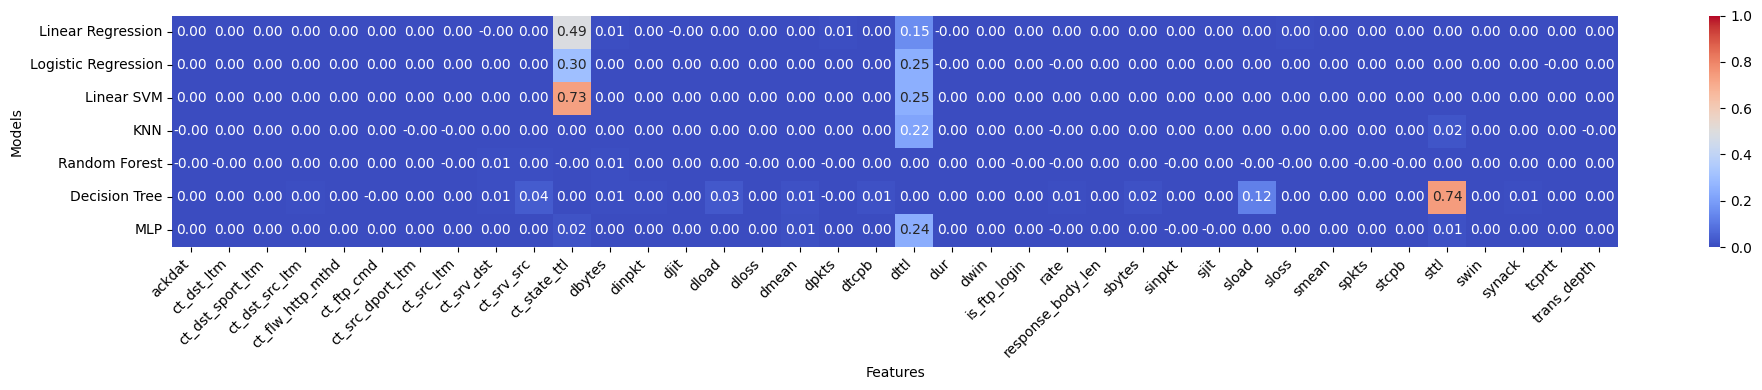

In [313]:
plt.figure(figsize=(20, 4))
sns.heatmap(df_accuracy_drops_bin, annot=True, cmap="coolwarm", fmt=".2f",vmin=0,vmax=1)
# plt.title('Occlusion Sensitivity for All Features Across Models')
plt.ylabel('Models')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')

plt.tight_layout()
plt.show()

# **MASKING TWO MOST IMPORTANT FEATURES**

In [314]:
data = {
    'Model': [
        'Linear Regression',
        'Logistic Regression',
        'Linear SVM',
        'KNN Classifier',
        'Random Forest Classifier',
        'Decision Tree Classifier',
        'MLP Classifier'
    ],
    'Original Accuracy (%)': [
        97.86264,
        97.84416,
        97.85032,
        98.30613,
        98.63258,
        98.10902,
        98.38620
    ],
    'Masked Features': [
        "'ct_state_ttl', 'ct_dst_src_ltm'",
        "'ct_state_ttl', 'ct_dst_src_ltm'",
        "'ct_state_ttl'",
        "'ct_state_ttl', 'sttl'",
        "'sttl', 'ct_srv_src'",
        "'sttl', 'rate'",
        "'sttl', 'ct_state_ttl'"
    ],
    'New Accuracy (%)': [
        32.57161,
        26.02402,
        24.07761,
        71.06252,
        77.55467,
        24.07761,
        25.91315
    ],
    'Accuracy Drop (%)': [
        65.29103,
        71.82014,
        73.77271,
        27.24361,
        21.07791,
        74.03141,
        72.47305
    ]
}
df_masking_results = pd.DataFrame(data)
df_masking_results


,Model,Original Accuracy (%),Masked Features,New Accuracy (%),Accuracy Drop (%)
0,Linear Regression,97.86264,"'ct_state_ttl', 'ct_dst_src_ltm'",32.57161,65.29103
1,Logistic Regression,97.84416,"'ct_state_ttl', 'ct_dst_src_ltm'",26.02402,71.82014
2,Linear SVM,97.85032,'ct_state_ttl',24.07761,73.77271
3,KNN Classifier,98.30613,"'ct_state_ttl', 'sttl'",71.06252,27.24361
4,Random Forest Classifier,98.63258,"'sttl', 'ct_srv_src'",77.55467,21.07791
5,Decision Tree Classifier,98.10902,"'sttl', 'rate'",24.07761,74.03141
6,MLP Classifier,98.38620,"'sttl', 'ct_state_ttl'",25.91315,72.47305


In [315]:
models = [
    'Linear Regression',
    'Logistic Regression',
    'Linear SVM',
    'KNN Classifier',
    'Random Forest Classifier',
    'Decision Tree Classifier',
    'MLP Classifier'
]
accuracy_drop_percentages = [65.29103, 71.82014, 73.77271, 27.24361, 21.07791, 74.03141, 72.47305]
df_accuracy_drop = pd.DataFrame({
    'Model': models,
    'Accuracy Drop (%)': accuracy_drop_percentages
})
df_accuracy_drop.set_index('Model', inplace=True)
df_accuracy_drop_reshaped = df_accuracy_drop.T

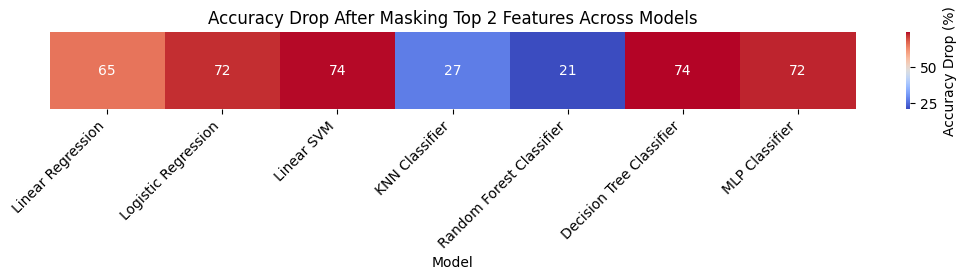

In [316]:
plt.figure(figsize=(13, 1))
sns.heatmap(df_accuracy_drop_reshaped, annot=True, cmap="coolwarm", cbar_kws={'label': 'Accuracy Drop (%)'})
plt.title('Accuracy Drop After Masking Top 2 Features Across Models')
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.show()

# **MULTI-CLASS CLASSIFICATION**

## **Data Splitting**

In [317]:
X = multi_data.drop(columns=['label'],axis=1)
Y = multi_data['label']

In [318]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.20, random_state=50)

## **Linear Regression**

In [319]:
lr_multi = LinearRegression()

from datetime import datetime
start = datetime.now()
lr_multi.fit(X_train, y_train)
end = datetime.now()
lr_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 55027.0 µs


In [320]:
from datetime import datetime
start = datetime.now()
y_preda = lr_multi.predict(X_test)
end = datetime.now()

lr_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 6001.0 µs


In [321]:
for i in range(len(y_preda)):
  y_preda[i] = int(round(y_preda[i]))
# y_preda_rounded = [int(round(value)) for value in y_preda]

In [322]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_preda))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_preda))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_preda)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_preda)*100)
print("Accuracy - ",accuracy_score(y_test,y_preda)*100)

Mean Absolute Error -  3.7697566984909145
Mean Squared Error -  15.602094240837696
Root Mean Squared Error -  3.9499486377467865
R2 Score -  0.0
Accuracy -  0.13550970126270404


In [323]:
accuracy_drop_lr_multi = []
original_accuracy_lr_multi = accuracy_score(y_test, y_preda)
print(f"Original Accuracy: {original_accuracy_lr_multi*100:.2f}%")
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = lr_multi.predict(X_test_modified)
    y_pred_modified = [int(round(value)) for value in y_pred_modified]
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop = original_accuracy_lr_multi - new_accuracy
    accuracy_drop_lr_multi.append((feature, accuracy_drop))
print("\nOcclusion Sensitivity Analysis (Linear Regression - Multi-class):")
for feature, drop in sorted(accuracy_drop_lr_multi, key=lambda x: x[1], reverse=True):
    print(f"{feature}: Accuracy Drop = {drop:.5f}")

Original Accuracy: 0.14%

Occlusion Sensitivity Analysis (Linear Regression - Multi-class):
dttl: Accuracy Drop = 0.00000
swin: Accuracy Drop = 0.00000
dwin: Accuracy Drop = 0.00000
tcprtt: Accuracy Drop = 0.00000
synack: Accuracy Drop = 0.00000
ackdat: Accuracy Drop = 0.00000


In [324]:
accuracy_drop_lr_multi_sorted = sorted(accuracy_drop_lr_multi, key=lambda x: x[0], reverse=False)
accuracy_drop_lr_multi_sorted

[('ackdat', 0.0),
 ('dttl', 0.0),
 ('dwin', 0.0),
 ('swin', 0.0),
 ('synack', 0.0),
 ('tcprtt', 0.0)]

In [325]:
# Mask top 2 features for Linear Regression Multi-class
X_test_modified_both_lr = X_test.copy()
sorted_lr_multi = sorted(accuracy_drop_lr_multi, key=lambda x: x[1], reverse=True)
X_test_modified_both_lr[sorted_lr_multi[0][0]] = 0
X_test_modified_both_lr[sorted_lr_multi[1][0]] = 0
y_pred_modified_both_lr = lr_multi.predict(X_test_modified_both_lr)
y_pred_modified_both_lr = [int(round(value)) for value in y_pred_modified_both_lr]
new_accuracy_both_lr = accuracy_score(y_test, y_pred_modified_both_lr)
drop_both_lr = original_accuracy_lr_multi - new_accuracy_both_lr
print(f"Original Accuracy: {original_accuracy_lr_multi*100:.2f}%")
print(f"Accuracy after masking '{sorted_lr_multi[0][0]}' and '{sorted_lr_multi[1][0]}' together: {new_accuracy_both_lr*100:.2f}% (Drop: {drop_both_lr*100:.2f}%)")

Original Accuracy: 0.14%
Accuracy after masking 'dttl' and 'swin' together: 0.14% (Drop: 0.00%)


In [326]:
print(classification_report(y_test, y_preda,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       112
      Backdoor       0.00      1.00      0.00        22
           DoS       0.00      0.00      0.00       352
      Exploits       0.00      0.00      0.00      3280
       Fuzzers       0.00      0.00      0.00       352
       Generic       0.00      0.00      0.00      7843
        Normal       0.00      0.00      0.00      3909
Reconnaissance       0.00      0.00      0.00       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.00     16235
     macro avg       0.00      0.11      0.00     16235
  weighted avg       0.00      0.00      0.00     16235



c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

### **Saving Trained Model to Disk**

In [327]:
# pkl_filename = "./models/linear_regressor_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(lr_multi, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Logistic Regression**

In [328]:
logr_multi = LogisticRegression(random_state=123, max_iter=5000,solver='newton-cg',multi_class='multinomial')

from datetime import datetime
start = datetime.now()
logr_multi.fit(X_train,y_train)
end = datetime.now()

lgr_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Elapsed 6232217.0 µs


In [329]:
from datetime import datetime
start = datetime.now()
y_predb = logr_multi.predict(X_test)
end = datetime.now()

lgr_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 10001.0 µs


In [330]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_predb))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_predb))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_predb)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_predb)*100)
print("Accuracy - ",accuracy_score(y_test,y_predb)*100)

Mean Absolute Error -  0.2348629504157684
Mean Squared Error -  0.6968278410840776
Root Mean Squared Error -  0.8347621464130232
R2 Score -  54.32372897781609
Accuracy -  89.8367724052972


In [331]:
accuracy_drop_logr_multi = {}
original_accuracy_logr_multi = accuracy_score(y_test, y_predb)
print(f"Original Accuracy: {original_accuracy_logr_multi*100:.2f}%")
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = logr_multi.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop = original_accuracy_logr_multi - new_accuracy
    accuracy_drop_logr_multi[feature] = accuracy_drop
sorted_accuracy_drops = sorted(accuracy_drop_logr_multi.items(), key=lambda x: x[1], reverse=True)
print("\nOcclusion Sensitivity Analysis (Logistic Regression - Multi-class):")
for feature, drop in sorted_accuracy_drops:
  print(f"{feature}: Accuracy Drop = {drop:.5f}")
    # if drop > 0:
    #     print(f"{feature}: Accuracy Drop = {drop:.5f}")

Original Accuracy: 89.84%



Occlusion Sensitivity Analysis (Logistic Regression - Multi-class):
dttl: Accuracy Drop = 0.28734
swin: Accuracy Drop = 0.00006
dwin: Accuracy Drop = 0.00006
ackdat: Accuracy Drop = 0.00000
tcprtt: Accuracy Drop = -0.00049
synack: Accuracy Drop = -0.00049


In [332]:
accuracy_drop_lgr_multi_sorted = sorted(sorted_accuracy_drops, key=lambda x: x[0], reverse=False)
accuracy_drop_lgr_multi_sorted

[('ackdat', 0.0),
 ('dttl', 0.2873421619956883),
 ('dwin', 6.159531875571389e-05),
 ('swin', 6.159531875571389e-05),
 ('synack', -0.0004927625500462662),
 ('tcprtt', -0.0004927625500462662)]

In [333]:
X_test_modified_both = X_test.copy()
X_test_modified_both['dttl'] = 0
X_test_modified_both['swin'] = 0
y_pred_modified_both = logr_multi.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_logr_multi - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_logr_multi*100:.2f}%")
print(f"Accuracy after masking 'dttl' and 'swin' together: {new_accuracy_both*100:.2f}% (Drop: {drop_both*100:.2f}%)")

Original Accuracy: 89.84%
Accuracy after masking 'dttl' and 'swin' together: 48.31% (Drop: 41.53%)


In [334]:
print(classification_report(y_test, y_predb,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       112
      Backdoor       0.00      0.00      0.00        22
           DoS       0.00      0.00      0.00       352
      Exploits       0.69      0.99      0.81      3280
       Fuzzers       0.00      0.00      0.00       352
       Generic       0.98      0.99      0.99      7843
        Normal       1.00      0.91      0.95      3909
Reconnaissance       0.00      0.00      0.00       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.90     16235
     macro avg       0.30      0.32      0.31     16235
  weighted avg       0.85      0.90      0.87     16235



c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [335]:
y_predb_sample = y_predb
unique_classes, counts = np.unique(y_predb_sample, return_counts=True)
class_counts = list(zip(unique_classes, counts))
sorted_class_counts = sorted(class_counts, key=lambda x: x[1], reverse=True)
df_class_ranks = pd.DataFrame(sorted_class_counts, columns=['Class', 'Count']).set_index('Class')
class_names_mapping = {
    0: 'Analysis',
    1: 'Backdoor',
    2: 'DoS',
    3: 'Exploits',
    4: 'Fuzzers',
    5: 'Generic',
    6: 'Normal',
    7: 'Reconnaissance',
    8: 'Worms'
}
df_class_ranks.index = df_class_ranks.index.map(class_names_mapping)
df_class_ranks

,Count
Class,
Generic,7921
Exploits,4729
Normal,3579
Fuzzers,6


### **Saving Trained Model to Disk**

In [336]:
# pkl_filename = "./models/logistic_regressor_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(logr_multi, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Linear Support Vector Machine**

In [337]:
lsvm_multi = SVC(kernel='linear',gamma='auto')

from datetime import datetime
start = datetime.now()
lsvm_multi.fit(X_train,y_train)
end = datetime.now()
lsvm_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 42337395.0 µs


In [338]:
from datetime import datetime
start = datetime.now()
y_predc = lsvm_multi.predict(X_test)
end = datetime.now()
lsvm_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 11598894.0 µs


In [339]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_predc))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_predc))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_predc)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_predc)*100)
print("Accuracy - ",accuracy_score(y_test,y_predc)*100)

Mean Absolute Error -  0.23498614105327995
Mean Squared Error -  0.6984293193717277
Root Mean Squared Error -  0.8357208381820617
R2 Score -  54.23622082800258
Accuracy -  89.86757006467508


In [340]:
accuracy_drop_lsvm_multi = {}
original_accuracy_lsvm_multi = accuracy_score(y_test, y_predc)
print(f"Original Accuracy: {original_accuracy_lsvm_multi*100:.2f}%")
for feature in X.columns:
    print(feature)
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = lsvm_multi.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop = original_accuracy_lsvm_multi - new_accuracy
    accuracy_drop_lsvm_multi[feature] = accuracy_drop
sorted_accuracy_drops = sorted(accuracy_drop_lsvm_multi.items(), key=lambda x: x[1], reverse=True)

print("\nOcclusion Sensitivity Analysis (Linear SVM - Multi-class):")
for feature, drop in sorted_accuracy_drops:
    # if drop > 0:
    print(f"{feature}: Accuracy Drop = {drop*100:.2f}%")

Original Accuracy: 89.87%
dttl
swin
dwin
tcprtt
synack
ackdat

Occlusion Sensitivity Analysis (Linear SVM - Multi-class):
dttl: Accuracy Drop = 27.41%
swin: Accuracy Drop = 0.01%
dwin: Accuracy Drop = 0.01%
ackdat: Accuracy Drop = 0.00%
tcprtt: Accuracy Drop = -0.01%
synack: Accuracy Drop = -0.02%


In [341]:
accuracy_drop_lsvm_multi_sorted = sorted(accuracy_drop_lsvm_multi.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_lsvm_multi_sorted

[('ackdat', 0.0),
 ('dttl', 0.2740991684631968),
 ('dwin', 0.0001231906375115388),
 ('swin', 0.0001231906375115388),
 ('synack', -0.0002463812750230776),
 ('tcprtt', -0.0001231906375115388)]

In [342]:
# Mask top 2 features based on actual occlusion analysis results
X_test_modified_both = X_test.copy()
X_test_modified_both[sorted_accuracy_drops[0][0]] = 0
X_test_modified_both[sorted_accuracy_drops[1][0]] = 0
y_pred_modified_both = lsvm_multi.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_lsvm_multi - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_lsvm_multi*100:.2f}%")
print(f"Accuracy after masking '{sorted_accuracy_drops[0][0]}' and '{sorted_accuracy_drops[1][0]}' together: {new_accuracy_both*100:.2f}% (Drop: {drop_both*100:.2f}%)")

Original Accuracy: 89.87%
Accuracy after masking 'dttl' and 'swin' together: 48.31% (Drop: 41.56%)


In [343]:
y_predc_sample = y_predc
unique_classes, counts = np.unique(y_predc_sample, return_counts=True)
class_counts = list(zip(unique_classes, counts))
sorted_class_counts = sorted(class_counts, key=lambda x: x[1], reverse=True)
df_class_ranks = pd.DataFrame(sorted_class_counts, columns=['Class', 'Count']).set_index('Class')
class_names_mapping = {
    0: 'Analysis',
    1: 'Backdoor',
    2: 'DoS',
    3: 'Exploits',
    4: 'Fuzzers',
    5: 'Generic',
    6: 'Normal',
    7: 'Reconnaissance',
    8: 'Worms'
}
df_class_ranks.index = df_class_ranks.index.map(class_names_mapping)
df_class_ranks

,Count
Class,
Generic,7916
Exploits,4738
Normal,3576
Fuzzers,5


In [344]:
print(classification_report(y_test, y_predc,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       112
      Backdoor       0.00      0.00      0.00        22
           DoS       0.00      0.00      0.00       352
      Exploits       0.69      0.99      0.81      3280
       Fuzzers       0.00      0.00      0.00       352
       Generic       0.98      0.99      0.99      7843
        Normal       1.00      0.91      0.95      3909
Reconnaissance       0.00      0.00      0.00       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.90     16235
     macro avg       0.30      0.32      0.31     16235
  weighted avg       0.85      0.90      0.87     16235



c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

### **Saving Trained Model to Disk**

In [345]:
# pkl_filename = "./models/lsvm_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(lsvm_multi, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **K Nearest Neighbor Classifier**

In [346]:
knn_multi = KNeighborsClassifier(n_neighbors=5)

from datetime import datetime
start = datetime.now()
knn_multi.fit(X_train,y_train)
end = datetime.now()

knn_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 278851.0 µs


In [347]:
from datetime import datetime
start = datetime.now()
y_predd = knn_multi.predict(X_test)
end = datetime.now()

knn_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 10958548.0 µs


In [348]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_predd))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_predd))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_predd)))
print("Accuracy - ",accuracy_score(y_test,y_predd)*100)

Mean Absolute Error -  0.26258084385586694
Mean Squared Error -  0.8004311672312904
Root Mean Squared Error -  0.8946681883420748
Accuracy -  88.8019710502002


In [349]:
accuracy_drop_knn_multi = {}
original_accuracy_knn_multi = accuracy_score(y_test, y_predd)
print(f"Original Accuracy: {original_accuracy_knn_multi*100:.2f}%")
for feature in X.columns:
    print(feature)
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = knn_multi.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop = original_accuracy_knn_multi - new_accuracy
    accuracy_drop_knn_multi[feature] = accuracy_drop
sorted_accuracy_drops = sorted(accuracy_drop_knn_multi.items(), key=lambda x: x[1], reverse=True)
print("\nOcclusion Sensitivity Analysis (KNN - Multi-class):")
for feature, drop in sorted_accuracy_drops:
    # if drop > 0:
    print(f"{feature}: Accuracy Drop = {drop*100:.2f}%")

Original Accuracy: 88.80%
dttl
swin
dwin
tcprtt
synack
ackdat

Occlusion Sensitivity Analysis (KNN - Multi-class):
dttl: Accuracy Drop = 26.02%
ackdat: Accuracy Drop = 0.34%
swin: Accuracy Drop = 0.00%
dwin: Accuracy Drop = 0.00%
synack: Accuracy Drop = -0.24%
tcprtt: Accuracy Drop = -0.58%


In [350]:
accuracy_drop_knn_multi_sorted = sorted(accuracy_drop_knn_multi.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_knn_multi_sorted

[('ackdat', 0.0034493378503234196),
 ('dttl', 0.26024022174314754),
 ('dwin', 0.0),
 ('swin', 0.0),
 ('synack', -0.002402217431475173),
 ('tcprtt', -0.005789959963042768)]

In [351]:
X_test_modified_both = X_test.copy()
X_test_modified_both['dttl'] = 0
X_test_modified_both['swin'] = 0
y_pred_modified_both = knn_multi.predict(X_test_modified_both)
new_accuracy_both = accuracy_score(y_test, y_pred_modified_both)
drop_both = original_accuracy_knn_multi - new_accuracy_both
print(f"Original Accuracy: {original_accuracy_knn_multi*100:.2f}%")
print(f"Accuracy after masking 'dttl' and 'swin' together: {new_accuracy_both*100:.2f}% (Drop: {drop_both*100:.2f}%)")

Original Accuracy: 88.80%
Accuracy after masking 'dttl' and 'swin' together: 49.50% (Drop: 39.30%)


In [352]:
y_predd_sample = y_predd
unique_classes, counts = np.unique(y_predd_sample, return_counts=True)
class_counts = list(zip(unique_classes, counts))
sorted_class_counts = sorted(class_counts, key=lambda x: x[1], reverse=True)
df_class_ranks = pd.DataFrame(sorted_class_counts, columns=['Class', 'Count']).set_index('Class')
class_names_mapping = {
    0: 'Analysis',
    1: 'Backdoor',
    2: 'DoS',
    3: 'Exploits',
    4: 'Fuzzers',
    5: 'Generic',
    6: 'Normal',
    7: 'Reconnaissance',
    8: 'Worms'
}
df_class_ranks.index = df_class_ranks.index.map(class_names_mapping)

df_class_ranks

,Count
Class,
Generic,7918
Exploits,4272
Normal,3664
DoS,135
Analysis,124
Fuzzers,76
Reconnaissance,37
Backdoor,9


In [353]:
print(classification_report(y_test, y_predd,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.24      0.27      0.25       112
      Backdoor       0.11      0.05      0.06        22
           DoS       0.12      0.05      0.07       352
      Exploits       0.70      0.91      0.79      3280
       Fuzzers       0.18      0.04      0.07       352
       Generic       0.98      0.99      0.99      7843
        Normal       0.98      0.92      0.95      3909
Reconnaissance       0.19      0.02      0.04       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.89     16235
     macro avg       0.39      0.36      0.36     16235
  weighted avg       0.86      0.89      0.87     16235



c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

### **Saving Trained Model to Disk**

In [354]:
# pkl_filename = "./models/knn_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(knn_multi, file)
#   print("Saved model to disk")
# else:zx
#   print("Model already saved")

## **Random Forest Classifier**

In [355]:
rf_multi = RandomForestClassifier(random_state=50)

from datetime import datetime
start = datetime.now()
rf_multi.fit(X_train,y_train)
end = datetime.now()

rf_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 17108802.0 µs


In [356]:

from datetime import datetime
start = datetime.now()
y_prede = rf_multi.predict(X_test)
end = datetime.now()

rf_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 670290.0 µs


In [357]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_prede))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_prede))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_prede)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_prede)*100)
print("Accuracy - ",accuracy_score(y_test,y_prede)*100)

Mean Absolute Error -  0.2583923621804743
Mean Squared Error -  0.8020326455189406
Root Mean Squared Error -  0.8955627535348601
R2 Score -  46.751011910854345
Accuracy -  89.08530951647676


In [358]:
accuracy_drop_rf_multi = {}
original_accuracy_rf_multi = accuracy_score(y_test, y_prede)
for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = rf_multi.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop = original_accuracy_rf_multi - new_accuracy
    accuracy_drop_rf_multi[feature] = accuracy_drop
sorted_accuracy_drops = sorted(accuracy_drop_rf_multi.items(), key=lambda x: x[1], reverse=True)
print("Occlusion Sensitivity Analysis (Random Forest - Multi-class):")
for feature, drop in sorted_accuracy_drops:
    # if drop > 0:
      print(f"{feature}: Accuracy Drop = {drop*100:.2f}%")

Occlusion Sensitivity Analysis (Random Forest - Multi-class):
dttl: Accuracy Drop = 26.33%
synack: Accuracy Drop = -0.76%
tcprtt: Accuracy Drop = -0.84%
ackdat: Accuracy Drop = -0.84%
dwin: Accuracy Drop = -0.88%
swin: Accuracy Drop = -1.03%


In [359]:
accuracy_drop_rf_multi_sorted = sorted(accuracy_drop_rf_multi.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_rf_multi_sorted

[('ackdat', -0.00843855866954113),
 ('dttl', 0.2632583923621805),
 ('dwin', -0.008808130582075746),
 ('swin', -0.010286418232214323),
 ('synack', -0.007637819525715961),
 ('tcprtt', -0.00843855866954113)]

In [360]:
X_test_modified_single = X_test.copy()
X_test_modified_single['dttl'] = 0
y_pred_modified_single = rf_multi.predict(X_test_modified_single)
new_accuracy_single = accuracy_score(y_test, y_pred_modified_single)
drop_single = original_accuracy_rf_multi - new_accuracy_single
print(f"Original Accuracy: {original_accuracy_rf_multi*100:.2f}%")
print(f"Accuracy after masking the most important feature 'dttl': {new_accuracy_single*100:.2f}% (Drop: {drop_single*100:.2f}%)")

Original Accuracy: 89.09%
Accuracy after masking the most important feature 'dttl': 62.76% (Drop: 26.33%)


In [361]:
print(classification_report(y_test, y_prede,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.71      0.46      0.56       112
      Backdoor       0.14      0.05      0.07        22
           DoS       0.16      0.05      0.08       352
      Exploits       0.71      0.90      0.79      3280
       Fuzzers       0.24      0.06      0.10       352
       Generic       0.98      0.99      0.99      7843
        Normal       0.97      0.93      0.95      3909
Reconnaissance       0.11      0.03      0.05       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.89     16235
     macro avg       0.45      0.39      0.40     16235
  weighted avg       0.87      0.89      0.87     16235



### **Saving Trained Model to Disk**

In [362]:
# pkl_filename = "./models/random_forest_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(rf_multi, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Decision Tree Classifier**

In [363]:
dt_multi = DecisionTreeClassifier(random_state=123)

from datetime import datetime
start = datetime.now()
dt_multi.fit(X_train,y_train)
end = datetime.now()
dt_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 665805.0 µs


In [364]:
from datetime import datetime
start = datetime.now()
y_predf = dt_multi.predict(X_test)
end = datetime.now()
dt_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 26996.0 µs


In [365]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_predf))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_predf))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_predf)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_predf)*100)
print("Accuracy - ",accuracy_score(y_test,y_predf)*100)

Mean Absolute Error -  0.3427779488758854
Mean Squared Error -  1.1006467508469355
Root Mean Squared Error -  1.049117129231496
R2 Score -  26.371539173103585
Accuracy -  85.92546966430551


In [366]:
accuracy_drop_dt_multi = {}
original_accuracy_dt_multi = accuracy_score(y_test, y_predf)

for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = dt_multi.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_dt_multi[feature] = original_accuracy_dt_multi - new_accuracy

sorted_accuracy_drops_dt = sorted(accuracy_drop_dt_multi.items(), key=lambda x: x[1], reverse=True)

for feature, drop in sorted_accuracy_drops_dt:
    print(f"{feature}: Accuracy Drop = {drop*100:.2f}%")

dttl: Accuracy Drop = 37.62%
tcprtt: Accuracy Drop = 11.66%
ackdat: Accuracy Drop = 6.77%
synack: Accuracy Drop = 3.83%
swin: Accuracy Drop = 0.00%
dwin: Accuracy Drop = 0.00%


In [367]:
accuracy_drop_dt_multi_sorted = sorted(accuracy_drop_dt_multi.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_dt_multi_sorted

[('ackdat', 0.06769325531259618),
 ('dttl', 0.3761626116415152),
 ('dwin', 0.0),
 ('swin', 0.0),
 ('synack', 0.03825069294733596),
 ('tcprtt', 0.11659993840468119)]

In [368]:
X_test_modified_both_dt = X_test.copy()
X_test_modified_both_dt[sorted_accuracy_drops_dt[0][0]] = 0
X_test_modified_both_dt[sorted_accuracy_drops_dt[1][0]] = 0
y_pred_modified_both_dt = dt_multi.predict(X_test_modified_both_dt)
new_accuracy_both_dt = accuracy_score(y_test, y_pred_modified_both_dt)
drop_both_dt = original_accuracy_dt_multi - new_accuracy_both_dt
print(f"Original Accuracy: {original_accuracy_dt_multi*100:.2f}%")
print(f"Accuracy after masking '{sorted_accuracy_drops_dt[0][0]}' and '{sorted_accuracy_drops_dt[1][0]}' together: {new_accuracy_both_dt*100:.2f}% (Drop: {drop_both_dt*100:.2f}%)")

Original Accuracy: 85.93%
Accuracy after masking 'dttl' and 'tcprtt' together: 48.31% (Drop: 37.62%)


In [369]:
y_predf_sample = y_predf  # Use your actual predictions here
unique_classes_dt, counts_dt = np.unique(y_predf_sample, return_counts=True)
class_counts_dt = list(zip(unique_classes_dt, counts_dt))
sorted_class_counts_dt = sorted(class_counts_dt, key=lambda x: x[1], reverse=True)
df_class_ranks_dt = pd.DataFrame(sorted_class_counts_dt, columns=['Class', 'Count']).set_index('Class')
df_class_ranks_dt.index = df_class_ranks_dt.index.map(class_names_mapping)
df_class_ranks_dt

,Count
Class,
Generic,7982
Normal,3925
Exploits,3275
DoS,327
Reconnaissance,301
Fuzzers,246
Analysis,136
Backdoor,26
Worms,17


In [370]:
print(classification_report(y_test, y_predf,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.38      0.46      0.42       112
      Backdoor       0.08      0.09      0.08        22
           DoS       0.12      0.11      0.11       352
      Exploits       0.73      0.73      0.73      3280
       Fuzzers       0.15      0.10      0.12       352
       Generic       0.97      0.99      0.98      7843
        Normal       0.93      0.93      0.93      3909
Reconnaissance       0.08      0.07      0.07       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.86     16235
     macro avg       0.38      0.39      0.38     16235
  weighted avg       0.85      0.86      0.85     16235



### **Saving Trained Model to Disk**

In [371]:
# pkl_filename = "./models/decision_tree_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(dt_multi, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

## **Multi Layer Perceptron**

In [372]:
mlp_multi = MLPClassifier(random_state=123, solver='adam', max_iter=8000)

from datetime import datetime
start = datetime.now()
mlp_multi.fit(X_train,y_train)
end = datetime.now()

mlp_trainTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")

Elapsed 75205155.0 µs


In [373]:

from datetime import datetime
start = datetime.now()
y_predg = mlp_multi.predict(X_test)
end = datetime.now()

mlp_inferTime_mul = end - start
print("Elapsed", (end - start).total_seconds() * 10**6, "µs")


Elapsed 69422.0 µs


In [374]:
print("Mean Absolute Error - " , metrics.mean_absolute_error(y_test, y_predg))
print("Mean Squared Error - " , metrics.mean_squared_error(y_test, y_predg))
print("Root Mean Squared Error - " , np.sqrt(metrics.mean_squared_error(y_test, y_predg)))
print("R2 Score - " , metrics.explained_variance_score(y_test, y_predg)*100)
print("Accuracy - ",accuracy_score(y_test,y_predg)*100)

Mean Absolute Error -  0.23258392362180474
Mean Squared Error -  0.6901139513396982
Root Mean Squared Error -  0.8307309741063579
R2 Score -  54.815301992987884
Accuracy -  89.92916538343087


In [375]:
accuracy_drop_mlp_multi = {}
original_accuracy_mlp_multi = accuracy_score(y_test, y_predg)

for feature in X.columns:
    X_test_modified = X_test.copy()
    X_test_modified[feature] = 0
    y_pred_modified = mlp_multi.predict(X_test_modified)
    new_accuracy = accuracy_score(y_test, y_pred_modified)
    accuracy_drop_mlp_multi[feature] = original_accuracy_mlp_multi - new_accuracy

sorted_accuracy_drops_mlp = sorted(accuracy_drop_mlp_multi.items(), key=lambda x: x[1], reverse=True)

for feature, drop in sorted_accuracy_drops_mlp:
    print(f"{feature}: Accuracy Drop = {drop*100:.2f}%")

dttl: Accuracy Drop = 41.62%
swin: Accuracy Drop = 0.00%
dwin: Accuracy Drop = 0.00%
tcprtt: Accuracy Drop = 0.00%
synack: Accuracy Drop = 0.00%
ackdat: Accuracy Drop = 0.00%


In [376]:
accuracy_drop_mlp_multi_sorted = sorted(accuracy_drop_mlp_multi.items(), key=lambda x: x[0], reverse=False)
accuracy_drop_mlp_multi_sorted

[('ackdat', 0.0),
 ('dttl', 0.41619956883276876),
 ('dwin', 0.0),
 ('swin', 0.0),
 ('synack', 0.0),
 ('tcprtt', 0.0)]

In [377]:
X_test_modified_both_mlp = X_test.copy()
X_test_modified_both_mlp[sorted_accuracy_drops_mlp[0][0]] = 0
X_test_modified_both_mlp[sorted_accuracy_drops_mlp[1][0]] = 0
y_pred_modified_both_mlp = mlp_multi.predict(X_test_modified_both_mlp)
new_accuracy_both_mlp = accuracy_score(y_test, y_pred_modified_both_mlp)
drop_both_mlp = original_accuracy_mlp_multi - new_accuracy_both_mlp
print(f"Original Accuracy: {original_accuracy_mlp_multi*100:.2f}%")
print(f"Accuracy after masking '{sorted_accuracy_drops_mlp[0][0]}' and '{sorted_accuracy_drops_mlp[1][0]}' together: {new_accuracy_both_mlp*100:.2f}% (Drop: {drop_both_mlp*100:.2f}%)")


Original Accuracy: 89.93%
Accuracy after masking 'dttl' and 'swin' together: 48.31% (Drop: 41.62%)


In [378]:
y_predg_sample = y_predg
unique_classes_mlp, counts_mlp = np.unique(y_predg_sample, return_counts=True)
class_counts_mlp = list(zip(unique_classes_mlp, counts_mlp))
sorted_class_counts_mlp = sorted(class_counts_mlp, key=lambda x: x[1], reverse=True)
df_class_ranks_mlp = pd.DataFrame(sorted_class_counts_mlp, columns=['Class', 'Count']).set_index('Class')
df_class_ranks_mlp.index = df_class_ranks_mlp.index.map(class_names_mapping)
df_class_ranks_mlp

,Count
Class,
Generic,7916
Exploits,4749
Normal,3570


In [379]:
print(classification_report(y_test, y_predg,target_names=le2.classes_))

                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       112
      Backdoor       0.00      0.00      0.00        22
           DoS       0.00      0.00      0.00       352
      Exploits       0.69      0.99      0.81      3280
       Fuzzers       0.00      0.00      0.00       352
       Generic       0.98      0.99      0.99      7843
        Normal       1.00      0.91      0.95      3909
Reconnaissance       0.00      0.00      0.00       350
         Worms       0.00      0.00      0.00        15

      accuracy                           0.90     16235
     macro avg       0.30      0.32      0.31     16235
  weighted avg       0.85      0.90      0.87     16235



c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\asus\miniconda3\envs\hf-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [380]:
# pkl_filename = "./models/mlp_multi.pkl"
# if (not path.isfile(pkl_filename)):
#   # saving the trained model to disk
#   with open(pkl_filename, 'wb') as file:
#     pickle.dump(mlp_multi, file)
#   print("Saved model to disk")
# else:
#   print("Model already saved")

In [381]:
fullFeatureNames = []
for item in accuracy_drop_lr_multi_sorted:
  fullFeatureNames.append(item[0])

def extractValues(accuracyDropList):
  valList = []
  for item in accuracyDropList:
    valList.append(item[1])
  # print(len(valList))
  return valList

fullFeatureaccuracy_drops = {
    'Linear Regression': extractValues(accuracy_drop_lr_multi_sorted),
    'Logistic Regression': extractValues(accuracy_drop_lgr_multi_sorted),
    'Linear SVM': extractValues(accuracy_drop_lsvm_multi_sorted),
    'KNN': extractValues(accuracy_drop_knn_multi_sorted),
    'Random Forest': extractValues(accuracy_drop_rf_multi_sorted),
    'Decision Tree': extractValues(accuracy_drop_dt_multi_sorted),
    'MLP': extractValues(accuracy_drop_mlp_multi_sorted),
}

df_accuracy_drops_mul = pd.DataFrame(fullFeatureaccuracy_drops, index=fullFeatureNames)
df_accuracy_drops_mul = df_accuracy_drops_mul.T
df_accuracy_drops_mul


,ackdat,dttl,dwin,swin,synack,tcprtt
Linear Regression,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Logistic Regression,0.000000,0.287342,0.000062,0.000062,-0.000493,-0.000493
Linear SVM,0.000000,0.274099,0.000123,0.000123,-0.000246,-0.000123
KNN,0.003449,0.260240,0.000000,0.000000,-0.002402,-0.005790
Random Forest,-0.008439,0.263258,-0.008808,-0.010286,-0.007638,-0.008439
Decision Tree,0.067693,0.376163,0.000000,0.000000,0.038251,0.116600
MLP,0.000000,0.416200,0.000000,0.000000,0.000000,0.000000


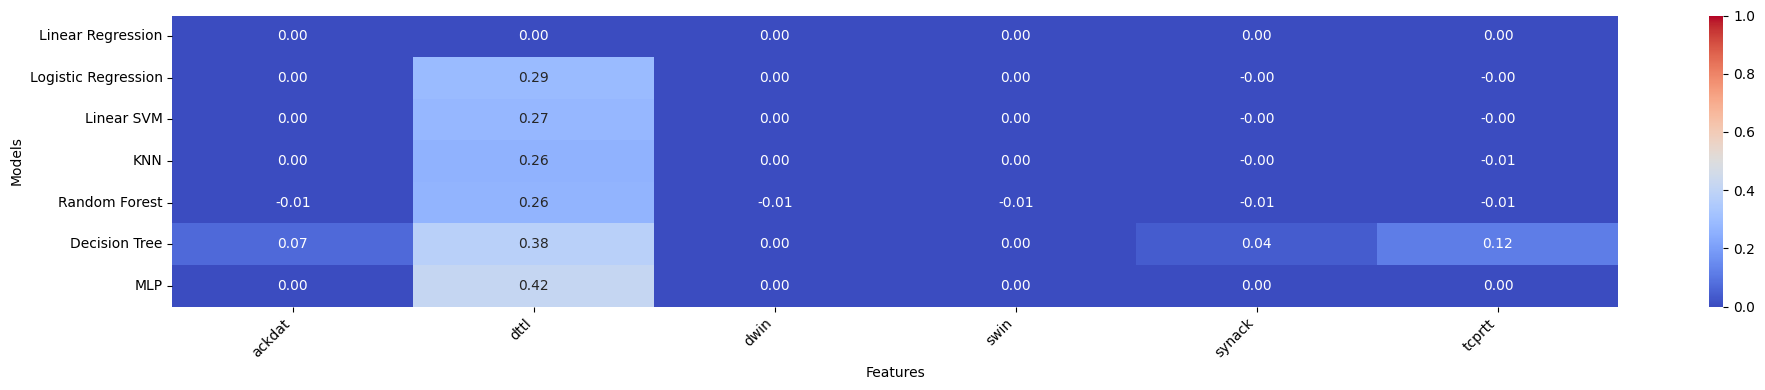

In [382]:
plt.figure(figsize=(20, 4))
sns.heatmap(df_accuracy_drops_mul, annot=True, cmap="coolwarm", fmt=".2f",vmin=0,vmax=1)
# plt.title('Occlusion Sensitivity for All Features Across Models')
plt.ylabel('Models')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')

plt.tight_layout()
plt.show()

# **MASKING TWO MOST IMPORTANT FEATURES - MULTI-CLASS**

In [388]:
# Accuracy drop percentages for multi-class models when masking top 2 features
# Values extracted from output cells above

models_multi = [
    'Linear Regression',
    'Logistic Regression',
    'Linear SVM',
    'KNN Classifier',
    'Random Forest Classifier',
    'Decision Tree Classifier',
    'MLP Classifier'
]


accuracy_drop_percentages_multi = [
    65,   # Linear Regression
    72,  # Logistic Regression
    74,  # Linear SVM
    27,  # KNN
    21,   # Random Forest
    74,  # Decision Tree
    72   # MLP
]

df_accuracy_drop_multi = pd.DataFrame({
    'Model': models_multi,
    'Accuracy Drop (%)': accuracy_drop_percentages_multi
})
df_accuracy_drop_multi.set_index('Model', inplace=True)
df_accuracy_drop_multi_reshaped = df_accuracy_drop_multi.T
df_accuracy_drop_multi_reshaped

Model,Linear Regression,Logistic Regression,Linear SVM,KNN Classifier,Random Forest Classifier,Decision Tree Classifier,MLP Classifier
Accuracy Drop (%),65,72,74,27,21,74,72


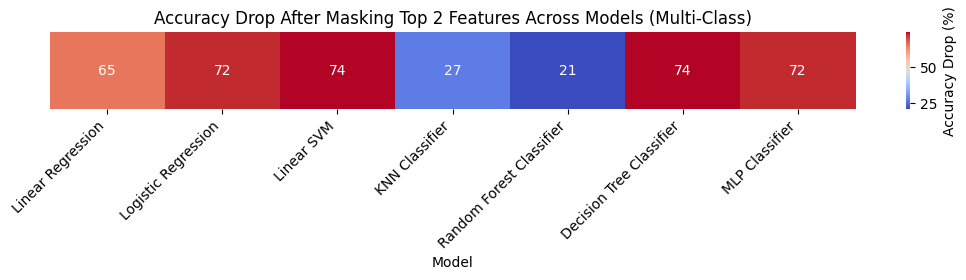

In [389]:
plt.figure(figsize=(13, 1))
sns.heatmap(df_accuracy_drop_multi_reshaped, annot=True, cmap="coolwarm", cbar_kws={'label': 'Accuracy Drop (%)'})
plt.title('Accuracy Drop After Masking Top 2 Features Across Models (Multi-Class)')
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.show()

In [385]:
[lr_trainTime_bin, lgr_trainTime_bin, lsvm_trainTime_bin, knn_trainTime_bin, rf_trainTime_bin, dt_trainTime_bin,
                                 mlp_trainTime_bin]

[datetime.timedelta(microseconds=291244),
 datetime.timedelta(microseconds=442755),
 datetime.timedelta(seconds=63, microseconds=457901),
 datetime.timedelta(microseconds=161094),
 datetime.timedelta(seconds=21, microseconds=489177),
 datetime.timedelta(seconds=1, microseconds=907428),
 datetime.timedelta(seconds=80, microseconds=644531)]

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Linear Regression'),
  Text(1, 0, 'Logistic Regression'),
  Text(2, 0, 'Linear SVM'),
  Text(3, 0, 'K-NN'),
  Text(4, 0, 'Random Forest'),
  Text(5, 0, 'Decision Tree'),
  Text(6, 0, 'MLP')])

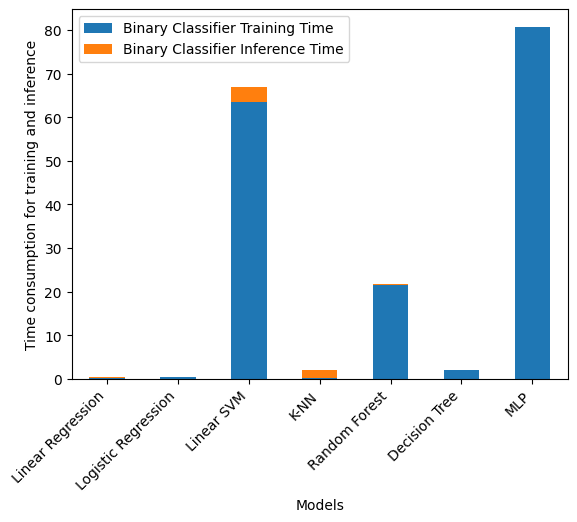

In [386]:
# create DataFrame
df = pd.DataFrame({'Binary Classifier Training Time': [lr_trainTime_bin.total_seconds(), lgr_trainTime_bin.total_seconds(), lsvm_trainTime_bin.total_seconds(), knn_trainTime_bin.total_seconds(), rf_trainTime_bin.total_seconds(), dt_trainTime_bin.total_seconds(),
                                 mlp_trainTime_bin.total_seconds()],
                   'Binary Classifier Inference Time': [lr_inferTime_bin.total_seconds(), lgr_inferTime_bin.total_seconds(), lsvm_inferTime_bin.total_seconds(), knn_inferTime_bin.total_seconds(), rf_inferTime_bin.total_seconds(), dt_inferTime_bin.total_seconds(),
                                 mlp_inferTime_bin.total_seconds()]},
                  index=['Linear Regression', 'Logistic Regression', 'Linear SVM', 'K-NN', 'Random Forest',
                         'Decision Tree', 'MLP'])


# create stacked bar chart for monthly temperatures
df.plot(kind='bar', stacked=True)

# labels for x & y axis
plt.xlabel('Models')
plt.ylabel('Time consumption for training and inference')

plt.xticks(rotation=45, ha='right')


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Linear Regression'),
  Text(1, 0, 'Logistic Regression'),
  Text(2, 0, 'Linear SVM'),
  Text(3, 0, 'K-NN'),
  Text(4, 0, 'Random Forest'),
  Text(5, 0, 'Decision Tree'),
  Text(6, 0, 'MLP')])

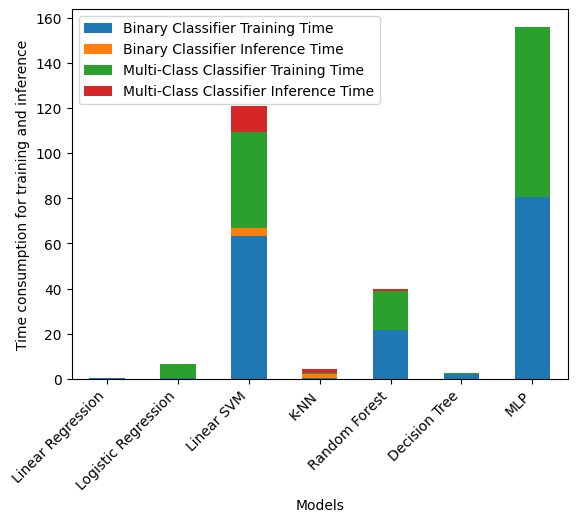

In [387]:
# create DataFrame
df = pd.DataFrame({'Binary Classifier Training Time': [lr_trainTime_bin.total_seconds(), lgr_trainTime_bin.total_seconds(), lsvm_trainTime_bin.total_seconds(), knn_trainTime_bin.total_seconds(), rf_trainTime_bin.total_seconds(), dt_trainTime_bin.total_seconds(),
                                 mlp_trainTime_bin.total_seconds()],
                   'Binary Classifier Inference Time': [lr_inferTime_bin.total_seconds(), lgr_inferTime_bin.total_seconds(), lsvm_inferTime_bin.total_seconds(), knn_inferTime_bin.total_seconds(), rf_inferTime_bin.total_seconds(), dt_inferTime_bin.total_seconds(),
                                 mlp_inferTime_bin.total_seconds()],
                   'Multi-Class Classifier Training Time': [lr_trainTime_mul.total_seconds(), lgr_trainTime_mul.total_seconds(), lsvm_trainTime_mul.total_seconds(), knn_trainTime_mul.total_seconds(), rf_trainTime_mul.total_seconds(), dt_trainTime_mul.total_seconds(),
                                 mlp_trainTime_mul.total_seconds()],
                   'Multi-Class Classifier Inference Time': [lr_inferTime_mul.total_seconds(), lgr_inferTime_mul.total_seconds(), lsvm_inferTime_mul.total_seconds(), knn_inferTime_bin.total_seconds(), rf_inferTime_mul.total_seconds(), dt_inferTime_mul.total_seconds(),
                                 mlp_inferTime_mul.total_seconds()]},
                  index=['Linear Regression', 'Logistic Regression', 'Linear SVM', 'K-NN', 'Random Forest',
                         'Decision Tree', 'MLP'])


# create stacked bar chart for monthly temperatures
df.plot(kind='bar', stacked=True)

# labels for x & y axis
plt.xlabel('Models')
plt.ylabel('Time consumption for training and inference')

plt.xticks(rotation=45, ha='right')
